# <div dir="rtl" style="text-align: right;">Queuechella - סימולציית פסטיבל מוזיקה</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<b>קבוצה 20</b> - סמסטר ב' 2026<br><br>
עידו מלאך - 318782208<br>
יונתן דולמן - 208987644<br>
איתן כהן - 322067448<br><br>
<b>תאריך הגשה:</b> 2026-06-29

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>צ'קליסט מחיקה לפני הגשה (חיפוש regex: <code>INTERNAL — DELETE BEFORE SUBMISSION</code>)</b><br><br>
1. למחוק את כל התאים בעלי הסימון הצהוב (כולל תא זה).<br>
2. לאמת שמקטע 20 (יומן שימוש ב-GenAI) מעודכן.<br>
3. לאמת שכל ארבעת התרשימים מוטמעים כתמונות ב-base64 במקטע 3.<br>
4. הרצה מקצה-לקצה לפני הגשה.<br>
5. ודאו שקובץ הנתונים <code>samples_for_simulation.xlsx</code> זמין להעלאה כשמריצים את מקטע 5 (תא הטעינה פותח חלון העלאה ב-Colab).<br>
6. למחוק הערות קוד המסומנות <code># [INTERNAL]</code> (חיפוש: <code>[INTERNAL]</code>).

</div>

## <div dir="rtl" style="text-align: right;">1. מבוא</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

פסטיבל המוזיקה **Queuechella** פועל יומיים רצופים, בכל יום בין השעות 09:00-20:00. הנהלת הפסטיבל מבקשת להעריך את איכות השירות והחוויה היומית של אורחיו, ולבחון האם כדאי להשקיע בשיפורים תחת תקציב נתון.

בעבודה זו אנו מדמים את הפסטיבל באמצעות **סימולציית אירועים בדידים** (Discrete-Event Simulation). האורחים מגיעים בשלושה סוגים - קבוצות חברים, זוגות ומבקרים יחידים - עוברים בעמדת כניסה ולאחריה נעים בין במות ההופעות ועמדות השירות. לכל אורח **מדד שביעות רצון** אישי (ערך התחלתי 5, בטווח 0-10) המתעדכן לאורך שהותו בפסטיבל.

**מטרת העבודה כפולה:**

- לאפיין את **המצב הקיים** - לכמת את שביעות רצון האורחים, זמני ההמתנה בתורים וההכנסות.
- לבחון **חלופות שיפור** - לבחור שילובי חלופות בתקציב של 1,000,000 ש״ח ולהשוות אותן למצב הקיים, באופן סטטיסטי ולוגי.

**מדדי הביצוע (KPIs)** שנבחנים בעבודה: שביעות רצון ממוצעת של האורחים ביציאה, זמן ההמתנה הממוצע והמרבי בתורים, וההכנסה הכוללת של הפסטיבל.

מבנה המחברת עוקב אחר סדר העבודה הנלמד: תיאור המערכת והנחות, תרשימי אירועים וטיפול, התאמת התפלגויות לנתונים, אלגוריתמי דגימה, מימוש מונחה-עצמים של רכיבי המערכת, לוגיקת הסימולציה, ולבסוף ניתוח המצב הקיים, בחינת החלופות וההמלצות.

</div>

## <div dir="rtl" style="text-align: right;">2. תיאור המערכת והנחות</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

בחלק זה נפרט את **המודל וההנחות** - כיצד בחרנו לייצג כל רכיב, בדגש על ההחלטות שאינן נובעות ישירות מהוראות העבודה. אנו ממדלים את הפסטיבל כמערכת **מסתיימת** (terminating): הוא נפתח ריק, פועל במשך יומיים ונסגר, ולכן הניתוח הסטטיסטי מתבצע על פני הרצות שלמות חוזרות ולא על מצב יציב.

**סוגי אורחים**

בפסטיבל שלושה סוגי אורחים הנבדלים בהתנהגותם, וכל אורח שייך ל**ישות** הנעה כיחידה אחת - איש אינו ממשיך לפעילות הבאה עד שכל חברי הישות סיימו את הנוכחית. **קבוצות חברים** פועלות בשני שלבים: תחילה הן צופות בהופעה אחת מכל סוג, ורק לאחר מכן עוברות בעמדות השירות. **זוגות** נעים לסירוגין בין הופעה לעמדת שירות, ואינם מתעניינים במוזיקה אלקטרונית. **מבקרים יחידים** ניגשים תחילה לאוהל המכירות, ומשם צופים במספר הופעות קבוע. קבוצות חברים ומבקרים יחידים מעדיפים בכל שלב את התור הקצר ביותר מבין הפעילויות שנותרו במסלולם, ואילו זוגות בוחרים את פעילותם הבאה באקראי - בהסתברות שווה בין האפשרויות.

**תנועה ותורים**

לכל ישות **סף סבלנות** בתור: אם ההמתנה חורגת ממנו, הישות נוטשת את התור, כל חבריה מאבדים נקודות משביעות רצונם, והיא ממשיכה לפעילות הבאה. בחרנו שנטישה אינה גוררת ניסיון חוזר באותה עמדה. עבור קבוצות חברים, העוברות בכל עמדה פעם אחת, העמדה שננטשה נגרעת מהמסלול והקבוצה אינה חוזרת אליה כלל באותו היום. זוגות, לעומת זאת, אינם פועלים לפי מסלול קבוע אלא בוחרים בכל פעם פעילות באקראי מבין כל האפשרויות, ולכן עמדה שננטשה עשויה להיבחר שוב במקרה בהמשך. נטישה אפשרית רק בארבע **עמדות השירות** (צילום, טעינה, מכירות וציורי פנים). להופעות, לעמדת הכניסה ולמתחם האוכל הישות תמיד ממתינה עד שמגיע תורה. בעמדות שבהן פועלים כמה שרתים במקביל, חברי אותה ישות מקבלים שירות **בו-זמנית** ככל שמתפנים שרתים, והישות ממשיכה הלאה רק לאחר שהחבר האחרון סיים. חברי הישות שסיימו את השירות אינם תופסים את השרת בזמן שהם מחכים לשאר הקבוצה.

**הופעות**

שלוש במות פועלות בפסטיבל: בשתיים מהן מתחלפות הופעות עם הפסקות קצרות ביניהן, ובבמת הדיג'יי מתנגנת מוזיקה אלקטרונית ברציפות. ככלל, אורחים נכנסים בסדר הגעתם. עם זאת, כאשר נותרו מעט מקומות פנויים, ישות קטנה הממתינה בהמשך התור עשויה להיכנס לפני ישות גדולה שאינה נכנסת במלואה. כאשר מתפנה מקום במהלך הופעה, הממתינים יכולים להצטרף. בבמה הראשית, חלק מהאורחים הניצבים במקומות המרוחקים עשויים לעזוב את ההופעה זמן קצר לאחר כניסתם - אך **קבוצות חברים פטורות** מכך, שכן הן מגיעות לצפות בהופעה במלואה ונשארות עד סופה.

**עמדות שירות**

עמדות השירות נבדלות באופן שבו אנו ממדלים את התנהגות החברים בישות. ב**עמדת הצילום** הישות מצטלמת יחד - תמונה אחת ותוצאה משותפת לכל החברים. לעומת זאת ב**אוהל המכירות** כל חבר קונה בנפרד, כך שכל אחד עשוי לרכוש פריטים שונים.

**אוכל**

בשעות הצהריים נפתחת בפני האורחים האפשרות לרכוש ארוחה במתחם האוכל, וכאן ריכזנו כמה החלטות מידול. ההחלטה אם לאכול והבחירה לאיזו מסעדה לגשת מתקבלות **פר חבר** ולא פר ישות - כך שבתוך קבוצה או זוג ייתכן שחלק מהחברים יאכלו ואחרים לא, וכל סועד בוחר מסעדה משלו. כל ישות עוצרת לאכול **פעם אחת ביום** לכל היותר, והעצירה מתאפשרת רק לאחר שהישות כבר סיימה פעילות אחת לכל הפחות (כלומר האכילה לעולם אינה הפעילות הראשונה). נוסף על כך מימשנו כלל של **איחוד הזמנות פיצה**: אדם בודד המעוניין בפיצה מזמין מנה אישית, אך כאשר כמה חברים באותה ישות בוחרים לאכול פיצה - הם חולקים מגשים משפחתיים (מגש משפחתי לעד שלושה). עבור כל מגש משפחתי - רק אחד מהחברים שיחלקו אותו יעמוד בתור לקופה. הישות ממשיכה לפעילות הבאה רק לאחר שכל הסועדים סיימו.

**שביעות רצון**

מדד שביעות הרצון של כל אורח מתעדכן לאורך הביקור: הוא **עולה** מחוויה טובה בהופעה, מתמונה מוצלחת או מציור פנים מוצלח, ו**יורד** מחוויה רעה בהופעה, מארוחה לא מספקת או מנטישת תור. המדד נשמר תמיד בתחום [0,10]. 

**לינה ומעבר בין ימים**

חלק מהאורחים נשארים ללון וממשיכים ליום השני. **קבוצות חברים** מחליטות על כך כבר בהגעתן, ו**זוגות** נשארים אם שביעות הרצון **הממוצעת** של שני בני הזוג גבוהה מ-7 בתום היום הראשון. ישות שנשארת ללון פותחת את היום השני ב**מסלול חדש** , עם תנאים זהים לאלו של היום הראשון. בתום כל יום, פעילויות שכבר החלו מסתיימות באופן טבעי לפני שהמערכת נסגרת.

החלטות אלה ואחרות מתורגמות למבנה האירועים, המוצג בתרשים האירועים ובתרשימי הטיפול שבמקטע הבא.

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b>

יומן החלטות התכנון המלא אינו משוכפל כאן. לפירוט המלא:

- `PLAN.md` §9 - רשימת 22 ההחלטות הנעולות ונימוקיהן.
- `DECISIONS_INVENTORY.md` - אינוונטר מלא של 58 ההחלטות שאינן נובעות מההנחיות, עם ציטוט מקור לכל אחת.

ההחלטות הנוגעות לחוויית האורח מתוארות במלל מקטע 2 שלמעלה.

</div>

## <div dir="rtl" style="text-align: right;">3. תרשים אירועים ותרשימי טיפול</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

סעיף זה כולל את <b>תרשים האירועים הכללי</b> של הסימולציה ושלושה <b>תרשימי טיפול</b> (flowcharts) המפרטים את הלוגיקה של האירועים המורכבים.

</div>

### <div dir="rtl" style="text-align: right;">3א. תרשים אירועים כללי</div>

<div align="center">
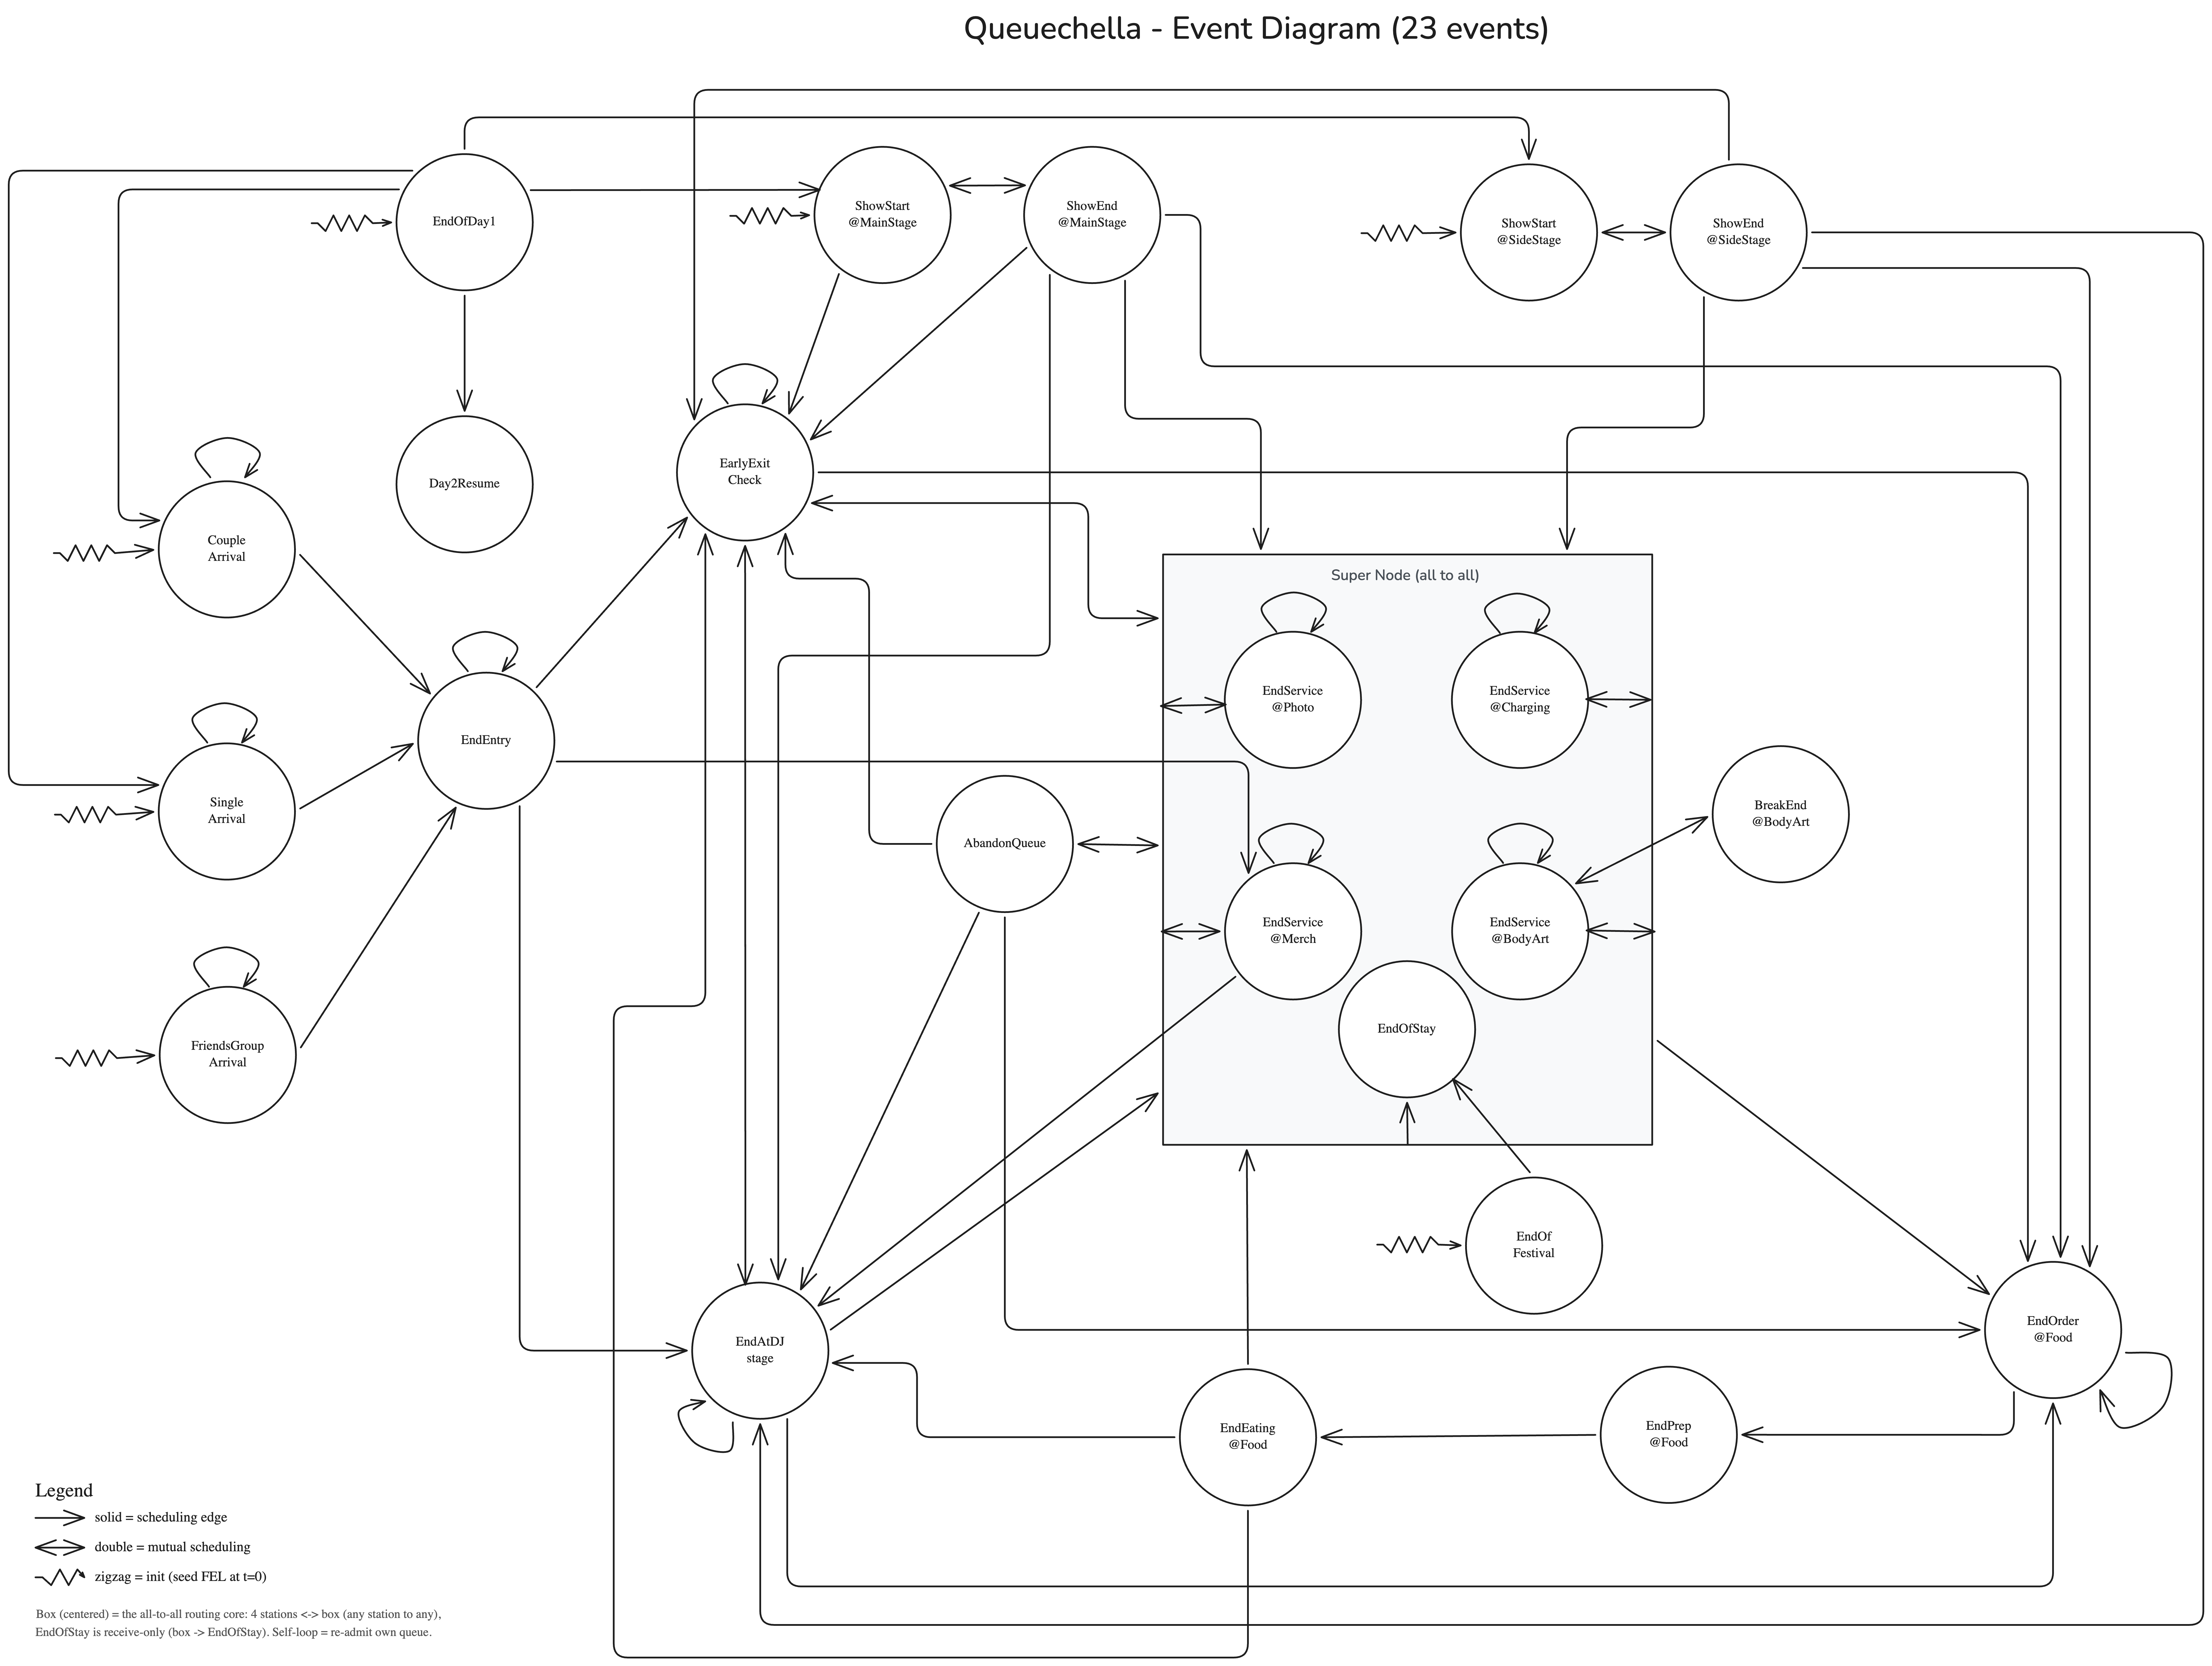
</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

התרשים מציג את 23 סוגי האירועים בסימולציה ואת קשרי התזמון ביניהם. כל מעגל הוא סוג אירוע יחיד. **חץ זיגזג** נכנס לאירוע שיש לזרוע ביומן האירועים בתחילת הריצה - שבעה אירועי פתיחה: שלוש ההגעות, שתי תחילות ההופעות ושני אירועי גבול-היום. **חץ מלא** מציין תזמון: כאשר אירוע אחד מתרחש הוא עשוי לדגום זמן הגעה של אירוע אחר, ולהכניס אותו ליומן האירועים, ולולאה עצמית היא אירוע העשוי לתזמן את המופע הבא של עצמו. חשוב להדגיש שהחץ אינו מתאר זרימה של ישות בין צמתים, אלא יחס תזמון בלבד - האפשרות שאירוע אחד יתזמן אירוע אחר.

**צומת-על (super-node).** ארבע עמדות השירות (צילום, טעינה, מכירות וציורי פנים) יחד עם אירוע היציאה מהפסטיבל מוקפים במלבן יחיד, המייצג צומת-על - מוסכמה שהוספנו בעצמנו ואינה חלק מהסימון שנלמד בכיתה. בחרנו בה משום שאירועי הסיום של ארבע העמדות מתזמנים זה את זה באופן הדדי (כל אחד עשוי לתזמן כל אחד), ובנוסף אירועים רבים שמחוץ למלבן עשויים לתזמן כל אחד מהם. ציור כל קשרי התזמון הללו בנפרד היה הופך את התרשים לבלתי קריא, ולכן ריכזנו אותם בצומת-על אחד.

משמעות החצים סביב צומת-העל:

- **חץ מאירוע חיצוני אל גבול המלבן** - כאשר אותו אירוע מתרחש, הוא עשוי לתזמן את אירוע הסיום של אחת מהעמדות שבמלבן (לדגום זמן ולהכניס ליומן את סיום השירות באחת מהן), מבלי שהחץ מחייב עמדה מסוימת מראש.
- **חץ הדדי בין עמדה שבתוך המלבן לבין גבול המלבן** - זהו הקיצור המרכזי שבזכותו המלבן נשאר קריא. עמדה המחוברת לגבול המלבן עשויה לתזמן את כל היעדים שאליהם מצביע המלבן, ובכלל זה: (א) כל אחד מהאירועים החיצוניים שאליהם יוצא חץ מגבול המלבן, וכן (ב) כל אחת משאר העמדות שבתוך המלבן - כלומר כל עמדה עשויה לתזמן את סיום השירות בכל עמדה אחרת. כך נחסך הצורך לצייר עשרות חצים נפרדים מכל עמדה לכל יעד.
- **חץ הנכנס או יוצא מצומת מסוימת בתוך המלבן** (ולא מגבול המלבן) מציין קשר תזמון ייחודי לאותו חבר בלבד - למשל, אירוע סיום הכניסה של מבקר יחיד מתזמן תמיד את סיום השירות באוהל המכירות, ולכן החץ מחובר ישירות לצומת זו ולא לגבול המלבן.
- **אירוע היציאה** הוא צומת ״מקבל בלבד״ בתוך צומת-העל: החצים מצביעים רק פנימה אליו. הסיבה היא שבכל מצב שבו אירוע עשוי לתזמן סיום שירות באחת מהעמדות, קיימת גם האפשרות שיתזמן במקום זאת את אירוע היציאה - ולכן קשרי התזמון אל היציאה מקופלים לתוך החצים הנכנסים אל המלבן.

</div>

### <div dir="rtl" style="text-align: right;">3ב. תרשים טיפול D1 - נטישת תור (AbandonQueue)</div>

<div align="center">
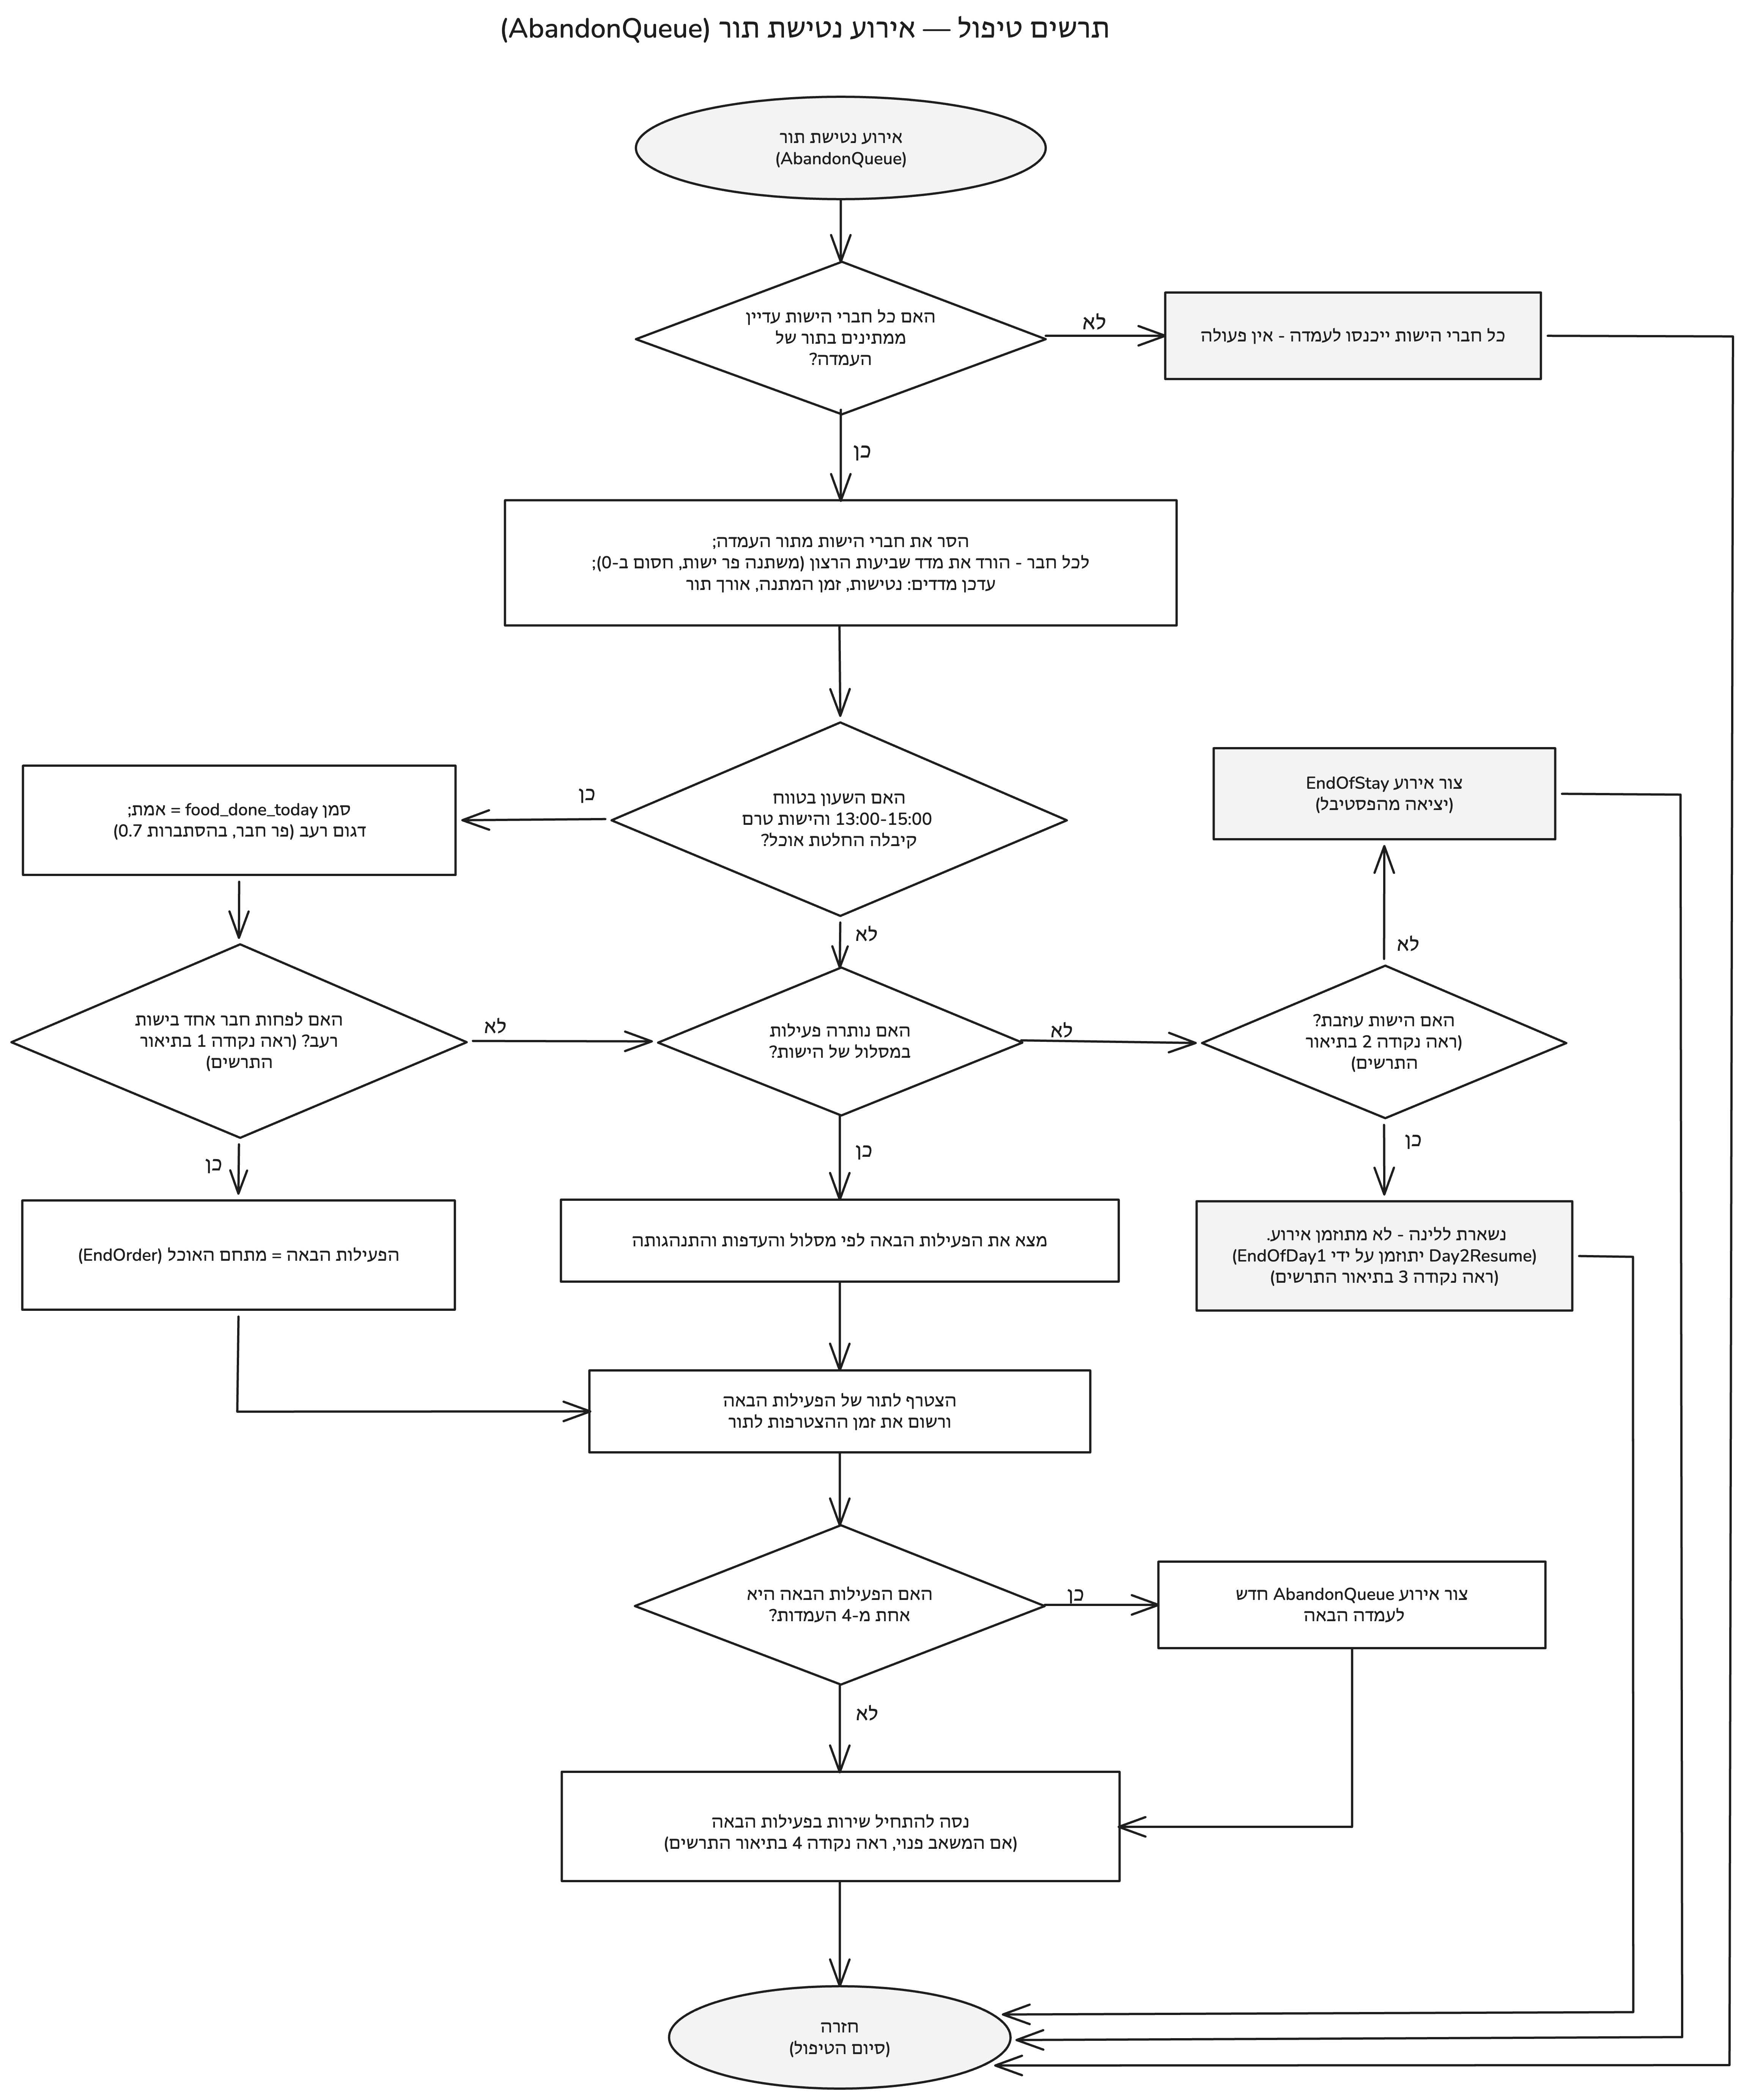
</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

**הסבר לתרשים D1 (נטישת תור).** חלק מהלוגיקה ארוכה מכדי להיכנס לאובייקטים בתרשים, ולכן היא מפורטת כאן לפי מספרי ההפניה.

**1. דגימת הרעב והעצירה לאכילה:**

- עבור כל חבר בישות נדגום רעב (ברנולי, P=0.7). אם לפחות חבר אחד רעב, כל הישות עוברת לדוכני האוכל, אך רק החברים הרעבים אוכלים בפועל. הדגימה מתבצעת פעם אחת ביום בלבד: היא מסומנת כבר ברגע הזכאות (גם אם בסופו של דבר איש אינו רעב), ולכן הישות לא תיבחן שוב לאכילה באותו יום.
- בשונה משאר האובייקטים בתרשים הפועלים ברמת הישות, מתחם האוכל ממודל ברמת החבר: חברים שונים באותה ישות עשויים לאכול במסעדות שונות ולדגום את אירוע ההזמנה (EndOrder) באופן עצמאי זה מזה.

**2. החלטת העזיבה (נבדקת רק לאחר שלא נותרה פעילות במסלול):**

ההחלטה אם הישות עוזבת או נשארת ללון נקבעת לפי סוגה:

- מבקרים יחידים עוזבים תמיד - על-פי ההנחיות הם אינם נשארים ללון.
- קבוצת חברים עוזבת אם לא רכשה כרטיס לינה בהגעתה, או אם זהו היום השני (האחרון). אחרת היא נשארת.
- זוג עוזב אם זהו היום השני, או אם החלטת הלינה שלו - הנקבעת ב-EndOfDay1 לפי שביעות רצון ממוצעת מעל 7 - הייתה ״לעזוב״. אחרת הוא נשאר.

**3. תוצאת ההישארות ללינה:**

ישות שנשארת ללון אינה מתזמנת אף אירוע ואינה מחזיקה משאב, אלא נותרת במצב המתנה סביל. אירוע EndOfDay1 (המתוזמן מראש לשעה 20:00) סורק את כלל הישויות החיות, ומתזמן עבור כל ישות שנשארה את אירוע Day2Resume לתחילת היום השני - שם היא פותחת מסלול חדש. תשלום הלינה אינו מתבצע במשבצת זו: קבוצת חברים שילמה את חבילת הלינה כבר בהגעתה, ותשלום הזוג (250 ש״ח לאדם) נגבה ב-EndOfDay1 בעת קבלת ההחלטה.

**4. דגימת השירות בפעילות הבאה (אם המשאב פנוי), לפי המנגנון הייחודי של אותה פעילות:**

- במה מרכזית: אם המקום הפנוי מספיק לכל חברי הישות, נכניסם, נדגום EarlyExitCheck ונעדכן את מספר המבלים.
- במה משנית: כנ״ל, אך ללא דגימה.
- במת הדיג'יי: כנ״ל, עם דגימת EndAtDJstage.
- שאר הפעילויות (כולל אוכל): הכניסה לשירות היא ברמת החבר ולא הישות - עבור כל שרת פנוי נשלוף חבר מהתור, נדגום עבורו זמן סיום שירות ונסמן את השרת כתפוס. החריג היחיד הוא עמדת הצילום, שבה הישות מצטלמת יחד (תמונה אחת ותוצאה משותפת), ולכן הדגימה בה היא ברמת הישות.

**הערות.** טיימר הנטישה נקבע בעת ההצטרפות לתור (זמן ההצטרפות בתוספת הזמן עד לנטישה: קבוצה 15, זוג 20, יחיד 20 דקות), ומבוטל כשאחד מחברי הישות מתחיל שירות (commit-on-first). קנס שביעות הרצון בנקודות: קבוצה 2, זוג 1.5, יחיד 1. שרשרת האוכל המלאה (EndOrder→EndPrep→EndEating) והטלות הרעב הפר-אורח מתבצעות בדגימת JIT ואינן חלק מטיפול זה.

</div>

### <div dir="rtl" style="text-align: right;">3ג. תרשים טיפול D2 - ShowStart במה מרכזית</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

*תרשים הטיפול עבור D2 (ShowStart בבמה המרכזית) יוטמע כאן עם השלמתו. הוא יתאר את לוגיקת הכניסה להופעה: מילוי עד הקיבולת לפי סדר ההגעה, פטור קבוצות החברים ממנגנון עשרת הרחוקים, ועיגון בדיקת העזיבה לפי זמן הכניסה.*

</div>

### <div dir="rtl" style="text-align: right;">3ד. תרשים טיפול D3 - סוף יום ראשון (EndOfDay1)</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

*תרשים הטיפול עבור D3 (סוף היום הראשון) יוטמע כאן עם השלמתו. הוא יתאר את מעבר היום: קבלת החלטות הלינה, זריעת אירועי יום שני, וטיפול בפעילויות שעדיין מתבצעות בעת הסגירה.*

</div>

## <div dir="rtl" style="text-align: right;">4. בחירת מדדים</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

ההנחיות מבקשות לבחור 2-3 מדדים לייעול. בחרנו בשלושה מדדים המכסים יחד את שלושת הממדים הרלוונטיים להערכת הפסטיבל - חוויית האורח, איכות התפעול וההיבט העסקי - כך שכל חלופה תיבחן בראייה מאוזנת.

- **שביעות רצון ממוצעת ביציאה:** זהו המדד המרכזי לחוויית האורח, וקיימת קורלציה בינו לבין שורת הרווח (דרך החלטת הלינה של זוגות). אנו מודדים אותו ברגע היציאה כדי לתפוס את השפעת הביקור כולו - ההופעות, השירותים והתורים.

- **זמן ההמתנה בתורים (ממוצע ומרבי):** מדד תפעולי הנגזר ישירות מזמן השירות. המתנות ארוכות פוגעות בחוויה ואף מובילות לנטישת תור. בחרנו במרבי לצד הממוצע משום שהממוצע לבדו עלול להסתיר צווארי בקבוק נקודתיים.

- **הכנסות הפסטיבל:** המדד המרכזי שנרצה למקסם - מטרת העל של הסימולציה. מאחר שכל חלופה כרוכה בעלות, יש לשקול את שיפור החוויה אל מול ההכנסות, ולוודא שאיננו משפרים את שביעות הרצון במחיר פגיעה בכדאיות הכלכלית של הפסטיבל.

שלושת המדדים יוצגו עבור המצב הקיים, וישמשו בהמשך להשוואה הסטטיסטית בין החלופות.

</div>

## <div dir="rtl" style="text-align: right;">הכנות - ייבוא ספריות וקבועי תצורה</div>

In [1]:
# Imports
import math
import heapq
import random
from enum import Enum
from collections import defaultdict
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import probplot
from scipy.special import digamma, polygamma
from IPython.display import display, HTML


<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b>

מיפוי החלופות (§17) - הפרמטרים ב-CONFIG שיש לשנות לכל חלופה (תקרת תקציב 1,000,000 ש״ח):

</div>

```
Better kitchen team       → food_unsatisfied_prob=0.1, food_choose_prob=0.85
Expanded security (+30%)  → stage_capacity_main=260, side=130, dj=91
Mainstream investment     → merch_band_shirt_prob=0.8, genre_score_main=4
Photo + BodyArt expansion → photo_servers=4, bodyart_artists=3
Advertising               → arrival_rate_multiplier=1.2
Auto entry                → entry_skip_scan=True
Visitor gifts             → initial_satisfaction=6.5
```

In [ ]:
"""All numeric and probabilistic parameters from the spec, as named constants.
Every value the Sampler and Simulation draw lives in this single CONFIG dict.
The parameters fitted in section 5 are stored at full precision.
"""

CONFIG = {
    # ---- Festival schedule ----
    "festival_open_hour": 9.0,             # 09:00
    "festival_close_hour": 20.0,           # 20:00
    "festival_days": 2,
    # FriendsGroup arrival window: 09:00-13:00 (Day 1 only, per spec)
    "fg_arrival_start_hour": 9.0,
    "fg_arrival_end_hour": 13.0,
    # Couple arrival window: 10:00-16:00 (both days, per spec)
    "couple_arrival_start_hour": 10.0,
    "couple_arrival_end_hour": 16.0,
    # Single arrival window: 09:00-16:00 (both days, per spec)
    "single_arrival_start_hour": 9.0,
    "single_arrival_end_hour": 16.0,

    # ---- Visitor satisfaction ----
    "initial_satisfaction": 5.0,
    "satisfaction_min": 0.0,
    "satisfaction_max": 10.0,

    # ---- Arrival rates (per minute) ----
    # FriendsGroup inter-arrival: Gamma (shape=r, rate=lambda), fitted in section 5א
    "fg_arrival_r":      1.239321,
    "fg_arrival_lambda": 0.903801,
    "couple_arrival_mean": 1.0,            # Couple: 60/hour -> mean gap 1 min
    # Single: 500 arrivals/day over the 09:00-16:00 window (420 min)
    "single_arrival_mean": (7.0 * 60.0) / 500.0,  # mean gap ≈ 0.84 min
    "arrival_rate_multiplier": 1.0,        # scales all arrival rates (1.0 = baseline)

    # ---- Group sizing ----
    "fg_size_min": 3,                      # DiscreteUniform[3,6]
    "fg_size_max": 6,
    "couple_size": 2,
    "single_size": 1,

    # ---- Entry ----
    "entry_clerks": 5,
    "entry_skip_scan": False,
    "entry_scan_low": 1.5,                 # U(1.5, 3) minutes
    "entry_scan_high": 3.0,
    "entry_security_mean": 2.0,            # Exp with mean 2 min

    # ---- MainStage (mainstream genre, G=3) ----
    "stage_capacity_main": 200,
    "main_show_break_min": 10.0,
    "main_show_mu":    45.902765,          # Normal mean (min), fitted in section 5ב
    "main_show_sigma":  8.927433,          # Normal std (min), fitted in section 5ב
    "main_farthest_n": 10,                 # 10 farthest entities re-evaluated
    "main_farthest_leave_prob": 0.5,       # Bernoulli at 15-min checkpoint
    "main_farthest_check_after_min": 15.0,
    "genre_score_main": 3,

    # ---- SideStage (indie genre, G=2) ----
    "stage_capacity_side": 100,
    "side_show_break_min": 5.0,
    "side_show_low":  20.0,                # U(20, 30) minutes
    "side_show_high": 30.0,
    "genre_score_side": 2,

    # ---- DJstage (electronic genre, G=1) ----
    "stage_capacity_dj": 70,
    # DJ piecewise PDF, support [20,60]; max f = 1/15 (jump-up at x=40). A/R envelope U(20,60):
    # c = M*(60-20) = (1/15)*40 = 8/3, acceptance = 3/8 ≈ 0.375.
    "dj_stay_low":  20.0,
    "dj_stay_high": 60.0,
    "dj_stay_max_pdf": 1.0 / 15.0,         # M for acceptance-rejection
    "dj_stay_envelope_c": 8.0 / 3.0,       # M * (b-a); acceptance rate = 1/c
    "genre_score_dj": 1,

    # ---- PhotoStation (service-time PDF sampled by composition) ----
    "photo_servers": 3,
    # CDF break points (derived in section 6.3):
    #   F(2) = 1/4,  F(3) = 7/8
    "photo_cdf_break_low":  0.25,
    "photo_cdf_break_high": 0.875,
    "photo_satisfied_prob": 0.7,
    "photo_satisfied_bonus": 2.0,
    "photo_unsatisfied_penalty_prob": 0.5, # if unsatisfied, Bernoulli for penalty
    "photo_unsatisfied_penalty": 0.5,      # subtracted
    "photo_print_price": 30,               # NIS, paid on satisfied outcome

    # ---- ChargingStation ----
    "charging_chargers": 150,
    "charging_battery_mu": 40.0,           # N(40, 15) for battery % on arrival
    "charging_battery_sigma": 15.0,
    # Charge-time PDF: f(t) = (alpha / 40^alpha) * (40-t)^(alpha-1), alpha = 100/(100-b)
    # Inverse-CDF: t = 40 * (1 - U^(1/alpha))
    "charging_max_minutes": 40.0,

    # ---- MerchTent ----
    "merch_servers": 7,                    # 7 registers
    "merch_service_low":  2.0,             # U(2, 6) minutes
    "merch_service_high": 6.0,
    # Per-member item Bernoulli probabilities + prices (NIS)
    "merch_shirt_prob":      0.8, "merch_shirt_price":      100,
    "merch_hat_prob":        0.4, "merch_hat_price":         50,
    "merch_flag_prob":       0.9, "merch_flag_price":        40,
    "merch_band_shirt_prob": 0.3, "merch_band_shirt_price": 200,

    # ---- BodyArt ----
    "bodyart_artists": 2,
    "bodyart_break_after_n": 10,           # 15-min break per 10 drawings per artist
    "bodyart_break_min": 15.0,
    # Picture-type choice probabilities (mutually exclusive)
    "bodyart_glitter_choose_prob": 0.3,
    "bodyart_neon_choose_prob":    0.3,
    "bodyart_henna_choose_prob":   0.4,
    # Duration distributions
    "bodyart_glitter_mu":    15.0,         # N(15, 3)
    "bodyart_glitter_sigma":  3.0,
    "bodyart_neon_mean":     12.0,         # Exp mean=12
    "bodyart_henna_low":     17.0,         # U(17, 22)
    "bodyart_henna_high":    22.0,
    # Per-type satisfaction probabilities + bonuses
    "bodyart_glitter_satisfied_prob": 0.7, "bodyart_glitter_bonus": 0.8,
    "bodyart_neon_satisfied_prob":    0.6, "bodyart_neon_bonus":    1.2,
    "bodyart_henna_satisfied_prob":   0.8, "bodyart_henna_bonus":   0.7,

    # ---- Food court (active 13:00-15:00 window per spec) ----
    "food_window_start_hour": 13.0,
    "food_window_end_hour":   15.0,
    "food_choose_prob": 0.7,
    # Restaurant choice probabilities (sum to 1)
    "food_choice_pizza":  0.25,            # 1/4
    "food_choice_burger": 0.375,           # 3/8
    "food_choice_asian":  0.375,           # remainder
    # Prep times (cashier → kitchen)
    "food_prep_pizza_low":  4.0,  "food_prep_pizza_high":  6.0,   # U(4, 6)
    "food_prep_burger_low": 3.0,  "food_prep_burger_high": 4.0,   # U(3, 4)
    "food_prep_asian_low":  3.0,  "food_prep_asian_high":  7.0,   # U(3, 7)
    # Register service (one register per restaurant)
    "food_register_mu":    5.0,                                    # N(5, 1.5)
    "food_register_sigma": 1.5,
    # Meal duration after receiving the food
    "food_meal_low":  15.0, "food_meal_high": 35.0,                # U(15, 35)
    # Prices (NIS)
    "food_pizza_personal_price": 40,       # Single only
    "food_pizza_family_price":  100,       # Couple + FriendsGroup (3+ people)
    "food_burger_price":        100,
    "food_asian_price":          65,
    # Unsatisfied outcome
    "food_unsatisfied_prob": 0.4,
    "food_unsatisfied_penalty": 0.6,

    # ---- Show satisfaction (per member) ----
    "show_satisfied_prob": 0.5,            # P(good experience)
    "show_bad_experience_penalty": 1.0,    # bad experience: -1
    # good: +(G-1)/genre_divisor + (T-1)/time_divisor  [G = genre 1-3, T = end-hour 9-20]
    "show_satisfaction_genre_divisor": 2,
    "show_satisfaction_time_divisor": 19,  # tuned so end-hour 20 -> +1.0

    # ---- Wait tolerance / abandonment ----
    "wait_tolerance_fg":     15.0,         # minutes
    "wait_tolerance_couple": 20.0,
    "wait_tolerance_single": 20.0,
    "wait_penalty_fg":     2.0,            # satisfaction lost per member on abandonment
    "wait_penalty_couple": 1.5,
    "wait_penalty_single": 1.0,

    # ---- Lodging / revenue ----
    "ticket_price":             500,       # NIS
    "lodging_addon_price":      250,       # Couple stay-over flat fee
    "ticket_plus_lodging_price": 700,      # FG pre-purchase price
    "fg_lodging_prob": 0.7,                # P(FG stays overnight, decided at arrival)
    "couple_lodging_threshold": 7.0,       # average of both members' satisfaction > 7

    # ---- RNG ----
    "master_seed": 20260628,
}


## <div dir="rtl" style="text-align: right;">5. התאמת התפלגות</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

קיבלנו שני אוספי נתונים אמפיריים מהפסטיבל, ועלינו להתאים לכל אחד מהם התפלגות הסתברותית שתשמש את הסימולציה - זמני בין-ההגעה של קבוצות החברים, ומשכי ההופעות בבמה הראשית. 

תהליך העבודה לכל סט נתונים:

- נפתח בבחינת מאפייני המדגם - תוחלת, פיזור ואסימטריה, וננסה להסיק איזו התפלגות תיאורטית תייצג אותם היטב.
- נאמוד את פרמטרי ההתפלגות בשיטת אומד הנראות המרבית, תוך פיתוח אנליטי מלא של המשוואות.
- נבדוק את ההתאמה באמצעות שני מבחני טיב התאמה - מבחן קולמוגורוב-סמירנוב ומבחן חי-בריבוע, ברמת מובהקות של 0.05.
- לבסוף נחזק את המסקנה בבדיקות גרפיות נוספות, ובהן תרשים Q-Q והשוואה בין פונקציית ההתפלגות המצטברת האמפירית לתיאורטית.

</div>

### <div dir="rtl" style="text-align: right;">5א. זמני בין-הגעה של קבוצות חברים - התפלגות גמא</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

עבור זמני בין-ההגעה של קבוצות החברים קיבלנו 100 תצפיות, בדקות. ההשערה הטבעית הראשונה לזמני בין-הגעה היא ההתפלגות המעריכית, ובה התחלנו. אמדנו אותה ובחנו את ההתאמה, אך להפתעתנו, היא נדחתה ברמת מובהקות של 0.05. לכן, עברנו להתפלגות גמא (שהיא הכללה טבעית של המעריכית - המעריכית עצמה מתקבלת ממנה כאשר פרמטר הצורה שווה ל-1, ואצלנו פרמטר הצורה יצא כ-1.24). נאמוד את פרמטרי הגמא בשיטת אומד הנראות המרבית ונבחן את טיב ההתאמה בשני מבחנים.

</div>

<div dir="rtl" style="background:#fff3cd; padding:10px; border-left:4px solid orange; margin:10px 0; font-size: 15px; line-height: 1.7;">
<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>
<b>החלפת השערה ראשונית מ-Exponential ל-Gamma (תיעוד החלטה).</b><br><br>
ההשערה הראשונית שלנו (לפי תכנית העבודה) הייתה Exponential, מקובלת לזמני בין-הגעה חסרי-זיכרון. בבחינה ראשונית של רגעי המדגם נמצאו סטיות מהותיות מהמעריכית:<br>
• <code>std/mean = 0.87</code> (במעריכית: 1.0)<br>
• <code>skewness = 1.29</code> (במעריכית: 2.0)<br>
• <code>excess kurtosis = 1.15</code> (במעריכית: 6.0)<br>
• הצפיפות בהיסטוגרמה מציגה mode סביב 0.5-1.0 דק' ולא באפס<br><br>
מבחן Chi-Square על השערת Exp נדחה ברמת מובהקות 0.05 עבור כל <code>k ∈ {5, 7, 8, 10}</code>. החלפנו את ההשערה ל-Gamma - הכללה טבעית של Exp (Gamma עם shape=1 = Exp), המאפשרת mode > 0 ומתאימה לרגעי המדגם. תוצאות ה-Gamma מוצגות בהמשך.<br><br>
<b>השלכה על M3:</b> ל-Gamma אין הופכי-CDF בצורה סגורה לפרמטר shape לא-שלם, ולכן שיטת Inverse-Transform אינה ישימה לזרם זה. נשתמש בשיטת <b>Acceptance-Rejection עם מעטפת מעריכית</b> - אותה שיטה הנדרשת לדגימה ב-DJ stage לפי המפרט, עם פיתוח מתמטי עצמאי המוצג ב-§6. שיעור הקבלה הצפוי ~89%.
</div>


#### <div dir="rtl" style="text-align: right;">אומד הנראות המרבית עבור התפלגות גמא</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

**Probability density function (PDF).** The Gamma distribution with shape $r$ and rate $\lambda$ has density:

$$
f(x, r, \lambda) = \frac{\lambda}{\Gamma(r)}\,(\lambda x)^{r-1}\, e^{-\lambda x} = \frac{\lambda^{r}}{\Gamma(r)}\, x^{r-1}\, e^{-\lambda x}, \qquad x \ge 0,\ r > 0,\ \lambda > 0,
$$

with mean $E[X] = r/\lambda$ and variance $\mathrm{Var}(X) = r/\lambda^2$.

---

**Likelihood.** Given a sample of $n$ independent observations drawn from the same distribution, $x_1, x_2, \dots, x_n$, the likelihood is the product of their densities:

$$
L(r, \lambda) = \prod_{i=1}^n \frac{\lambda^{r}}{\Gamma(r)}\, x_i^{r-1}\, e^{-\lambda x_i} = \frac{\lambda^{nr}}{\Gamma(r)^{\,n}}\left(\prod_{i=1}^n x_i\right)^{\!r-1} e^{-\lambda \sum_{i=1}^n x_i}
$$

---

**Log-likelihood.** Taking the natural logarithm, which turns it into a sum:

$$
\ell(r, \lambda) = \ln L(r, \lambda) = nr\ln\lambda - n\ln\Gamma(r) + (r-1)\sum_{i=1}^n \ln x_i - \lambda\sum_{i=1}^n x_i
$$

---

**Rate parameter (closed form).** We differentiate with respect to $\lambda$ and set the derivative to zero:

$$
\frac{\partial \ell}{\partial \lambda} = \frac{nr}{\lambda} - \sum_{i=1}^n x_i = 0
$$

Writing $\bar{x} = \frac{1}{n}\sum_i x_i$, the sum equals $n\bar{x}$, so $nr/\lambda = n\bar{x}$, and the rate estimate is

$$
\hat{\lambda} = \frac{\hat{r}}{\bar{x}}
$$

---

**Shape parameter (transcendental equation).** Differentiating with respect to $r$:

$$
\frac{\partial \ell}{\partial r} = n\ln\lambda - n\,\psi(r) + \sum_{i=1}^n \ln x_i = 0,
$$

where $\psi(r) = \frac{d}{dr}\ln\Gamma(r)$ is the digamma function. We substitute the rate we just found, $\hat{\lambda} = \hat{r}/\bar{x}$, so that $\ln\lambda = \ln\hat{r} - \ln\bar{x}$:

$$
n(\ln\hat{r} - \ln\bar{x}) - n\,\psi(\hat{r}) + \sum_{i=1}^n \ln x_i = 0
$$

Dividing by $n$ and rearranging leaves a single equation in $\hat{r}$:

$$
\boxed{\ \ln\hat{r} - \psi(\hat{r}) = \ln\bar{x} - \frac{1}{n}\sum_{i=1}^n \ln x_i\ }
$$

This equation has no closed-form solution, so we solve it numerically with Newton-Raphson:

$$
r_{k+1} = r_k - \frac{\ln r_k - \psi(r_k) - s}{1/r_k - \psi'(r_k)}, \qquad s = \ln\bar{x} - \frac{1}{n}\sum_{i=1}^n \ln x_i,
$$

starting from the method-of-moments seed $r_0 = \bar{x}^2 / s_x^2$ (with $s_x^2$ the sample variance). We evaluate $\psi$ and $\psi'$ with `scipy.special.digamma` and `scipy.special.polygamma(1, .)`. SciPy is parameterized by shape and scale, so we pass $\text{scale} = 1/\hat{\lambda}$.

</div>

In [ ]:
# FriendsGroup arrival intervals: Gamma distribution fit.
# Load data, MLE estimation (Newton-Raphson on the digamma equation),
# KS test, Chi-Square test (k=12 equal-probability bins), diagnostic plots.

try:
    from google.colab import files
    XLSX_PATH = list(files.upload().keys())[0]
except ImportError:
    XLSX_PATH = "samples_for_simulation.xlsx"
fg = pd.read_excel(XLSX_PATH, sheet_name="FriendsGroup_arrival_intervals")["minutes"].to_numpy()
n_fg = len(fg)

print("--- FG arrival intervals: summary statistics ---")
print(f"n        = {n_fg}")
print(f"min      = {fg.min():.4f}")
print(f"max      = {fg.max():.4f}")
print(f"mean     = {fg.mean():.4f}")
print(f"median   = {np.median(fg):.4f}")
print(f"std (MLE)= {fg.std(ddof=0):.4f}")
print(f"std/mean = {fg.std(ddof=0)/fg.mean():.4f}")
print(f"skewness = {stats.skew(fg):.4f}")
print(f"kurtosis = {stats.kurtosis(fg):.4f}  (excess; Normal = 0)")


def gamma_mle(data, tol=1e-10, max_iter=200):
    """MLE for Gamma(shape=r, rate=lambda) via Newton-Raphson on the digamma equation.

    Closed form: lambda_hat = r_hat / x_bar.
    r solves: ln(r) - psi(r) = ln(x_bar) - (1/n) sum ln(x_i).
    """
    x_bar = data.mean()
    s = np.log(x_bar) - np.log(data).mean()
    r = x_bar ** 2 / data.var(ddof=0)  # method-of-moments seed
    for _ in range(max_iter):
        f = np.log(r) - digamma(r) - s
        f_prime = 1.0 / r - polygamma(1, r)
        new_r = r - f / f_prime
        if abs(new_r - r) < tol:
            r = new_r
            break
        r = new_r
    lam = r / x_bar
    return float(r), float(lam)


r_hat, lambda_hat = gamma_mle(fg)
gamma_scale = 1.0 / lambda_hat  # SciPy's Gamma takes shape + scale (= 1/rate)
print("\n--- MLE estimates ---")
print(f"r_hat      (shape) = {r_hat:.6f}")
print(f"lambda_hat (rate)  = {lambda_hat:.6f}")
print(f"fitted mean = r/lambda   = {r_hat / lambda_hat:.4f}  (sample = {fg.mean():.4f})")
print(f"fitted var  = r/lambda^2 = {r_hat / lambda_hat ** 2:.4f}  (sample = {fg.var(ddof=0):.4f})")


# --- KS test (unmodified D, asymptotic critical 1.358/sqrt(n) at alpha=0.05) ---
def empirical_cdf(data):
    sorted_data = np.sort(data)
    n = len(sorted_data)
    return sorted_data, np.arange(1, n + 1) / n


def ks_d_statistic(data, cdf_func):
    sorted_data, ecdf = empirical_cdf(data)
    n = len(sorted_data)
    tcdf = cdf_func(sorted_data)
    d_plus = float(np.max(ecdf - tcdf))
    d_minus = float(np.max(tcdf - np.arange(0, n) / n))
    return max(d_plus, d_minus)


gamma_cdf_fit = lambda x: stats.gamma.cdf(x, r_hat, scale=gamma_scale)
gamma_inv_fit = lambda q: stats.gamma.ppf(q, r_hat, scale=gamma_scale)

ks_D_fg = ks_d_statistic(fg, gamma_cdf_fit)
ks_crit_fg = 1.358 / np.sqrt(n_fg)
ks_pass_fg = ks_D_fg < ks_crit_fg

print("\n--- KS test (alpha = 0.05) ---")
print(f"D                          = {ks_D_fg:.5f}")
print(f"critical (1.358 / sqrt(n)) = {ks_crit_fg:.5f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if ks_pass_fg else 'REJECT'}")


# --- Chi-Square test with equal-probability bins ---
def chi_square_eq_prob(data, inv_cdf, k, n_params, alpha_sig=0.05):
    n = len(data)
    edges = [-np.inf] + [inv_cdf(i / k) for i in range(1, k)] + [np.inf]
    observed, _ = np.histogram(data, bins=edges)
    expected = np.full(k, n / k)
    chi2_stat = float(np.sum((observed - expected) ** 2 / expected))
    df = k - 1 - n_params
    crit = float(stats.chi2.ppf(1 - alpha_sig, df))
    return chi2_stat, crit, df, observed.tolist()


K_BINS_FG = 12
chi2_fg, chi_crit_fg, df_fg, obs_fg = chi_square_eq_prob(fg, gamma_inv_fit, K_BINS_FG, n_params=2)
chi_pass_fg = chi2_fg < chi_crit_fg

print(f"\n--- Chi-Square test (k = {K_BINS_FG} equal-probability bins, alpha = 0.05) ---")
print(f"observed counts        = {obs_fg}")
print(f"expected per bin       = {n_fg / K_BINS_FG:.2f}")
print(f"chi-square statistic   = {chi2_fg:.4f}")
print(f"degrees of freedom     = {df_fg}  (k - 1 - p, p = 2 parameters estimated)")
print(f"critical value (0.95)  = {chi_crit_fg:.4f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if chi_pass_fg else 'REJECT'}")


# --- Diagnostic plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
y_jitter = np.random.default_rng(0).uniform(-1, 1, n_fg) * 0.1
ax.scatter(fg, y_jitter, alpha=0.6, s=22, edgecolor="white", linewidth=0.4)
ax.axvline(fg.mean(), color="red", linewidth=1.4, label=f"mean = {fg.mean():.3f}")
ax.axvline(np.median(fg), color="green", linestyle="--", linewidth=1.4, label=f"median = {np.median(fg):.3f}")
ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("minutes")
ax.set_title("Raw data (strip plot)")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)

ax = axes[0, 1]
ax.hist(fg, bins=20, density=True, alpha=0.55, edgecolor="black", label="empirical")
xx = np.linspace(0.01, fg.max(), 400)
ax.plot(xx, stats.gaussian_kde(fg)(xx), color="#8e44ad", linewidth=1.6, label="KDE (empirical density)")
ax.plot(xx, stats.gamma.pdf(xx, r_hat, scale=gamma_scale), "r-", linewidth=2,
        label=f"Gamma(r={r_hat:.3f}, λ={lambda_hat:.3f})")
ax.plot(xx, stats.expon.pdf(xx, scale=fg.mean()), "k--", linewidth=1.3,
        label=f"Exp(λ={1/fg.mean():.3f}) (rejected hypothesis)")
ax.set_xlabel("minutes"); ax.set_ylabel("density")
ax.set_title("Histogram + fitted Gamma PDF")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sorted_fg, ecdf_fg = empirical_cdf(fg)
ax.step(sorted_fg, ecdf_fg, where="post", label="empirical CDF")
ax.plot(sorted_fg, gamma_cdf_fit(sorted_fg), "r-", linewidth=2, label="fitted Gamma CDF")
ax.set_xlabel("minutes"); ax.set_ylabel("F(x)")
ax.set_title(f"Empirical vs fitted CDF  (KS D = {ks_D_fg:.4f})")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
probplot(fg, dist="gamma", sparams=(r_hat, 0, gamma_scale), plot=ax)
ax.get_lines()[0].set_markerfacecolor("#1f77b4"); ax.get_lines()[0].set_markeredgecolor("white")
ax.set_title("Q-Q plot vs fitted Gamma")
ax.grid(True, alpha=0.3)

fig.suptitle("FriendsGroup arrival intervals: Gamma fit diagnostics", fontsize=12)
fig.tight_layout()
plt.show()


#### <div dir="rtl" style="text-align: right;">מסקנות - התאמת התפלגות גמא</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

קיימת התאמה גבוהה בין הנתונים להתפלגות גמא. אומד הנראות המרבית נתן פרמטר צורה של כ-1.239 ופרמטר קצב של כ-0.904.

מעבר לאיכות ההתאמה, לבחירה בגמא יש יתרון משמעותי נוסף: מכיוון שפרמטר הקצב נאמד כיחס שבין פרמטר הצורה לממוצע, אומד הנראות המרבית שלה משחזר במדויק את ממוצע המדגם. כך קצב ההגעה בסימולציה נשאר נאמן לנתונים - תכונה חשובה במיוחד במידול תורים.

תוצאות מבחני טיב ההתאמה, ברמת מובהקות 0.05:

- מבחן קולמוגורוב-סמירנוב: הסטטיסטי שהתקבל (0.081) קטן מהערך הקריטי (0.136), ולכן אין דחייה.
- מבחן חי-בריבוע: הסטטיסטי (12.8) קטן מהערך הקריטי (16.92), ולכן אין דחייה.

גם התמונה הגרפית תומכת: תרשים ה-Q-Q, השוואת המצטברת התיאורטית לאמפירית וההיסטוגרמה עם פונקציית הצפיפות מצביעים כולם על התאמה טובה לאורך הטווח כולו. ההתפלגות המעריכית ששקלנו בתחילה מצוירת בהיסטוגרמה כקו מקווקו, וניתן לראות שהיא מתאימה פחות מהתפלגות גמא - שיא הצפיפות שלה יושב באפס, בעוד שבנתונים הערך השכיח נמצא סביב חצי דקה.

לסיכום, זמני בין-ההגעה של קבוצות החברים ידגמו מהתפלגות גמא עם פרמטר צורה 1.239 ופרמטר קצב 0.904, באמצעות אלגוריתם קבלה-דחייה עם מעטפת מעריכית (פיתוח בחלק 6).

</div>

### <div dir="rtl" style="text-align: right;">5ב. משך הופעות במה ראשית - התפלגות נורמלית</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

עבור משכי ההופעות בבמה הראשית קיבלנו 100 תצפיות, בדקות. משך הופעה נוטה להתרכז סביב ערך מרכזי, עם פיזור סימטרי פחות או יותר סביבו, ולכן ההשערה הטבעית כאן היא ההתפלגות הנורמלית. נאמוד את הפרמטרים בשיטת אומד הנראות המרבית ונבחן את טיב ההתאמה באותם שני מבחנים.

</div>

#### <div dir="rtl" style="text-align: right;">אומד הנראות המרבית עבור התפלגות נורמלית</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

**Probability density function (PDF).** The Normal distribution with mean $\mu$ and variance $\sigma^2$ has density

$$
f(x, \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\, \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \qquad x \in \mathbb{R},\ \sigma > 0
$$

---

**Likelihood.** Given a sample of $n$ independent observations drawn from the same distribution, $x_1, x_2, \dots, x_n$, the likelihood is the product of their densities:

$$
L(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}\, \exp\!\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right) = (2\pi\sigma^2)^{-n/2}\,\exp\!\left(-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2\right)
$$

---

**Log-likelihood.** Taking the natural logarithm turns the product into a sum:

$$
\ell(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2
$$

---

**Mean (closed form).** Differentiating with respect to $\mu$:

$$
\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^n (x_i - \mu) = 0
$$

The factor $1/\sigma^2$ is positive, so the sum itself must vanish: $\sum_i (x_i - \mu) = 0$, that is $\sum_i x_i = n\mu$. Hence

$$
\hat{\mu} = \bar{x}
$$

---

**Variance (closed form).** Differentiating with respect to $\sigma^2$ (treating $\sigma^2$ as one variable):

$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4}\sum_{i=1}^n (x_i - \mu)^2 = 0
$$

Multiplying through by $2\sigma^4$ gives $-n\sigma^2 + \sum_i (x_i-\mu)^2 = 0$, so

$$
\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2
$$

---

**Result.**

$$
\boxed{\ \hat{\mu} = \bar{x}, \qquad \hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2\ }
$$

The MLE for $\sigma^2$ divides by $n$ rather than $n-1$, so it is biased low. It is nonetheless consistent and converges to the true value as $n \to \infty$.

</div>

In [ ]:
# MainStage concert duration: Normal distribution fit.
# Load data, MLE estimation (closed form), KS test, Chi-Square test (k=12), diagnostic plots.
# Reuses empirical_cdf, ks_d_statistic, chi_square_eq_prob defined in the Gamma fit above.

ms = pd.read_excel(XLSX_PATH, sheet_name="MainStage_concert_duration")["minutes"].to_numpy()
n_ms = len(ms)

print("--- MS concert duration: summary statistics ---")
print(f"n        = {n_ms}")
print(f"min      = {ms.min():.4f}")
print(f"max      = {ms.max():.4f}")
print(f"mean     = {ms.mean():.4f}")
print(f"median   = {np.median(ms):.4f}")
print(f"std (MLE)= {ms.std(ddof=0):.4f}")
print(f"std/mean = {ms.std(ddof=0)/ms.mean():.4f}")
print(f"skewness = {stats.skew(ms):.4f}")
print(f"kurtosis = {stats.kurtosis(ms):.4f}  (excess; Normal = 0)")

# MLE (closed form)
mu_hat = float(ms.mean())
sigma2_hat = float(((ms - mu_hat) ** 2).sum() / n_ms)
sigma_hat = float(np.sqrt(sigma2_hat))

print("\n--- MLE estimates ---")
print(f"mu_hat     = {mu_hat:.6f}")
print(f"sigma2_hat = {sigma2_hat:.6f}  (divisor n, biased MLE)")
print(f"sigma_hat  = {sigma_hat:.6f}")

norm_cdf_fit = lambda x: stats.norm.cdf(x, loc=mu_hat, scale=sigma_hat)
norm_inv_fit = lambda q: stats.norm.ppf(q, loc=mu_hat, scale=sigma_hat)

ks_D_ms = ks_d_statistic(ms, norm_cdf_fit)
ks_crit_ms = 1.358 / np.sqrt(n_ms)
ks_pass_ms = ks_D_ms < ks_crit_ms

print("\n--- KS test (alpha = 0.05) ---")
print(f"D                          = {ks_D_ms:.5f}")
print(f"critical (1.358 / sqrt(n)) = {ks_crit_ms:.5f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if ks_pass_ms else 'REJECT'}")

K_BINS_MS = 12
chi2_ms, chi_crit_ms, df_ms, obs_ms = chi_square_eq_prob(ms, norm_inv_fit, K_BINS_MS, n_params=2)
chi_pass_ms = chi2_ms < chi_crit_ms

print(f"\n--- Chi-Square test (k = {K_BINS_MS} equal-probability bins, alpha = 0.05) ---")
print(f"observed counts        = {obs_ms}")
print(f"expected per bin       = {n_ms / K_BINS_MS:.2f}")
print(f"chi-square statistic   = {chi2_ms:.4f}")
print(f"degrees of freedom     = {df_ms}  (k - 1 - p, p = 2 parameters estimated)")
print(f"critical value (0.95)  = {chi_crit_ms:.4f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if chi_pass_ms else 'REJECT'}")


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
y_jitter = np.random.default_rng(1).uniform(-1, 1, n_ms) * 0.1
ax.scatter(ms, y_jitter, alpha=0.6, s=22, edgecolor="white", linewidth=0.4)
ax.axvline(mu_hat, color="red", linewidth=1.4, label=f"mean = {mu_hat:.3f}")
ax.axvline(np.median(ms), color="green", linestyle="--", linewidth=1.4, label=f"median = {np.median(ms):.3f}")
ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("minutes")
ax.set_title("Raw data (strip plot)")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)

ax = axes[0, 1]
ax.hist(ms, bins=20, density=True, alpha=0.55, edgecolor="black", label="empirical")
xx = np.linspace(ms.min(), ms.max(), 400)
ax.plot(xx, stats.gaussian_kde(ms)(xx), color="#8e44ad", linewidth=1.6, label="KDE (empirical density)")
ax.plot(xx, stats.norm.pdf(xx, mu_hat, sigma_hat), "r-", linewidth=2,
        label=f"Normal(μ={mu_hat:.2f}, σ={sigma_hat:.2f})")
ax.set_xlabel("minutes"); ax.set_ylabel("density")
ax.set_title("Histogram + fitted Normal PDF")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sorted_ms, ecdf_ms = empirical_cdf(ms)
ax.step(sorted_ms, ecdf_ms, where="post", label="empirical CDF")
ax.plot(sorted_ms, norm_cdf_fit(sorted_ms), "r-", linewidth=2, label="fitted Normal CDF")
ax.set_xlabel("minutes"); ax.set_ylabel("F(x)")
ax.set_title(f"Empirical vs fitted CDF  (KS D = {ks_D_ms:.4f})")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
probplot(ms, dist="norm", sparams=(mu_hat, sigma_hat), plot=ax)
ax.get_lines()[0].set_markerfacecolor("#1f77b4"); ax.get_lines()[0].set_markeredgecolor("white")
ax.set_title("Q-Q plot vs fitted Normal")
ax.grid(True, alpha=0.3)

fig.suptitle("MainStage concert duration: Normal fit diagnostics", fontsize=12)
fig.tight_layout()
plt.show()


#### <div dir="rtl" style="text-align: right;">מסקנות - התאמת התפלגות נורמלית</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

הנתונים מתאימים להתפלגות הנורמלית. לאומד הנראות המרבית תוחלת של כ-45.90 דקות וסטיית תקן של כ-8.93 דקות.

תוצאות מבחני טיב ההתאמה, ברמת מובהקות 0.05:

- מבחן קולמוגורוב-סמירנוב: הסטטיסטי שהתקבל (0.102) קטן מהערך הקריטי (0.136), ולכן אין דחייה.
- מבחן חי-בריבוע: הסטטיסטי (14.0) קטן מהערך הקריטי (16.92), ולכן אין דחייה.

ביחס לגודל המדגם, הבדיקות הגרפיות מראות התאמה סבירה. ניכרת הטיה שמאלית קלה, המתבטאת בנקודות הקיצוניות בזנב השמאלי של תרשים ה-Q-Q, אך היא מתונה מכדי להצדיק דחייה של ההתפלגות הנורמלית.

לסיכום, משכי ההופעות בבמה הראשית ידגמו מהתפלגות נורמלית עם תוחלת 45.90 וסטיית תקן 8.93, באמצעות אלגוריתם בוקס-מולר (פיתוח בחלק 6).

</div>

## <div dir="rtl" style="text-align: right;">6. אלגוריתמי דגימה</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

במקטע זה אנו מציגים את אלגוריתמי הדגימה עבור כל אחת מההתפלגויות במודל. נציג לכל אלגוריתם את הפיתוח המתמטי המלא, ולאחר מכן נממש את כלל האלגוריתמים במחלקת <code>Sampler</code>. כל הדגימות נשענות על מספרים פסאודו-אקראיים אחידים בתחום (0,1), שאותם אנו שולפים מתוך <code>RNGStreams</code> (המוגדרת בהמשך המקטע, לפני מחלקת ה-Sampler) - זרם נפרד לכל מקור אקראיות, כדי שנוכל לעשות שימוש חוזר במספרים אקראיים משותפים (CRN) כשנשווה בין החלופות.

עשינו שימוש בארבעה אלגוריתמי דגימה:

- **טרנספורם הופכי** - לכל ההתפלגויות שפונקציית ההתפלגות המצטברת שלהן ניתנת להיפוך  (אחידה, מעריכית, ברנולי, אחידה בדידה, וגם זמן הטעינה לאחר פיתוח).
- **בוקס-מולר** - לכל המשתנים הנורמליים (משך הופעה בבמה הראשית, אחוז סוללה, ציור נצנצים, ושירות בקופת האוכל).
- **קומפוזיציה** - לצפיפות בעמדת הצילום, על-ידי פירוק לתמהיל מקטעים, בחירת מקטע לפי משקלו וטרנספורם הופכי בתוכו.
- **קבלה-דחייה** - חובה לפי המפרט עבור משך השהות בבמת הדיג'י, ותשמש אותנו גם לדגימת מרווחי ההגעה של קבוצות החברים.

הטבלה הבאה ממפה כל גודל אקראי במודל להתפלגותו ולאלגוריתם הדגימה שלו:

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.6;">

<table style="margin-left:auto; margin-right:auto; border-collapse:collapse;">
<tr style="background:#eef;"><th style="padding:6px 12px; border:1px solid #aaa;">גודל אקראי</th><th style="padding:6px 12px; border:1px solid #aaa;">התפלגות</th><th style="padding:6px 12px; border:1px solid #aaa;">אלגוריתם</th></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">מרווח הגעה - קבוצת חברים</td><td style="padding:4px 12px; border:1px solid #aaa;">גמא (r≈1.24, λ≈0.90), נאמדה בחלק 5א</td><td style="padding:4px 12px; border:1px solid #aaa;">קבלה-דחייה (מעטפת מעריכית)</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">מרווח הגעה - זוג</td><td style="padding:4px 12px; border:1px solid #aaa;">מעריכית (תוחלת 1 דקה)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">מרווח הגעה - יחיד</td><td style="padding:4px 12px; border:1px solid #aaa;">מעריכית (תוחלת 420/500 דקה)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">גודל קבוצת חברים</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה בדידה {3, ..., 6}</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">סריקת כרטיס</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה (1.5, 3)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">בידוק ביטחוני</td><td style="padding:4px 12px; border:1px solid #aaa;">מעריכית (תוחלת 2)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך הופעה במה ראשית</td><td style="padding:4px 12px; border:1px solid #aaa;">נורמלית (μ≈45.9, σ≈8.93), נאמדה בחלק 5ב</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך הופעה במה משנית</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה (20, 30)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך שהות בבמת דיג'י</td><td style="padding:4px 12px; border:1px solid #aaa;">צפיפות במקטעים בתחום [20, 60]</td><td style="padding:4px 12px; border:1px solid #aaa;">קבלה-דחייה</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך צילום</td><td style="padding:4px 12px; border:1px solid #aaa;">צפיפות במקטעים בתחום [1, 4]</td><td style="padding:4px 12px; border:1px solid #aaa;">קומפוזיציה</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">אחוז סוללה בכניסה</td><td style="padding:4px 12px; border:1px solid #aaa;">נורמלית (μ=40, σ=15)</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך טעינה</td><td style="padding:4px 12px; border:1px solid #aaa;">צפיפות פרמטרית, α=100/(100−b)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי (לאחר גזירת F)</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך קנייה במרצ'נדייס</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה (2, 6)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">ציור נצנצים</td><td style="padding:4px 12px; border:1px solid #aaa;">נורמלית (μ=15, σ=3)</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">ציור ניאון</td><td style="padding:4px 12px; border:1px solid #aaa;">מעריכית (תוחלת 12)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">קעקוע חינה</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה (17, 22)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">הכנת פיצה / המבורגר / אסייתי</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה (תלוי במסעדה)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">שירות בקופה במתחם האוכל</td><td style="padding:4px 12px; border:1px solid #aaa;">נורמלית (μ=5, σ=1.5)</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך ארוחה</td><td style="padding:4px 12px; border:1px solid #aaa;">אחידה (15, 35)</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">החלטות ברנולי (לינה, סיפוק, פריטי מרצ', בחירת מסעדה ...)</td><td style="padding:4px 12px; border:1px solid #aaa;">ברנולי(p) או רב-קטגוריאלית</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
</table>

</div>

### <div dir="rtl" style="text-align: right;">6.1 טרנספורם הופכי</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

**(a) Continuous uniform $\mathcal{U}(a,b)$.**

$$
f(x) = \frac{1}{b-a},\quad a \le x \le b, \qquad F(x) = \frac{x-a}{b-a}, \qquad x = a + (b-a)\,u
$$

**(b) Exponential $\mathrm{Exp}(\lambda)$.**

$$
F(x) = 1 - e^{-\lambda x} = u \quad\text{gives}\quad x = -\frac{1}{\lambda}\ln(1-u)
$$

Since $1-U$ is also $\mathcal{U}(0,1)$, we use the equivalent shorter form

$$
x = -\,\mathrm{mean}\cdot\ln(u), \qquad \mathrm{mean} = 1/\lambda
$$

**(c) Discrete uniform $\{a, a+1, \dots, b\}$.** Each value has probability $1/(b-a+1)$, the step CDF is $F(k) = (k-a+1)/(b-a+1)$, and the standard inversion is

$$
x = a + \lfloor u\,(b-a+1) \rfloor
$$

In Queuechella this draws the FriendsGroup size (3 to 6 members).

**(d) Bernoulli $\mathrm{Bernoulli}(p)$.**

$$
X = \begin{cases} 1, & u < p \\ 0, & u \ge p \end{cases}
$$

This covers every binary decision: lodging purchase for a FriendsGroup, show satisfaction, buying a shirt / hat / flag / band-shirt, choosing to eat lunch, and so on.

**(e) Categorical.** A generalization of Bernoulli. Given $p_1 + \cdots + p_k = 1$ and $u \sim \mathcal{U}(0,1)$, return the first category $j$ whose cumulative sum $\sum_{i=1}^{j} p_i$ exceeds $u$. In the project: body-art type $(0.3, 0.3, 0.4)$ and restaurant choice $(1/4, 3/8, 3/8)$.

**(f) Inverse transform inside a parametric CDF (charge time).** See the separate derivation in section 6.6 - the CDF requires a parametric integration.

</div>

### <div dir="rtl" style="text-align: right;">6.2 בוקס-מולר - דגימה נורמלית</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

Inverse transform is not applicable to $\mathcal{N}(0,1)$ because $\Phi^{-1}$ has no closed form. Instead we use the geometric method of Box & Muller: given an independent pair $u_1, u_2 \sim \mathcal{U}(0,1)$, the variables

$$
Z_1 = \sqrt{-2\ln u_1}\,\cos(2\pi u_2), \qquad Z_2 = \sqrt{-2\ln u_1}\,\sin(2\pi u_2)
$$

are both $\mathcal{N}(0,1)$ and mutually independent. To reach a general $\mathcal{N}(\mu, \sigma^2)$ we use the linear-scaling property of the normal family:

$$
X = \mu + \sigma Z, \qquad Z \sim \mathcal{N}(0,1)
$$

---

**Algorithm (one draw from $\mathcal{N}(\mu, \sigma^2)$):**

1. Draw $u_1, u_2 \sim \mathcal{U}(0,1)$.
2. $z \leftarrow \sqrt{-2\ln u_1}\,\cos(2\pi u_2)$.
3. Return $x = \mu + \sigma z$.

---

In the model this method draws four normal quantities: MainStage concert duration $\mathcal{N}(45.90, 8.93^2)$ (parameters from section 5), entry battery percentage at the charging station $\mathcal{N}(40, 15^2)$, glitter body-art duration $\mathcal{N}(15, 3^2)$, and food-register service $\mathcal{N}(5, 1.5^2)$.

**Technical note.** Each call discards the second value $Z_2$, so $n$ calls consume $2n$ uniforms rather than $n$. We keep this uniform pattern for code clarity and to preserve a single RNG stream per source.

</div>

### <div dir="rtl" style="text-align: right;">6.3 קומפוזיציה - משך הצילום</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

By the spec, the PhotoStation service-time density (in minutes) is

$$
f(x) = \begin{cases} \dfrac{x}{6}, & 1 \le x < 2 \\[2pt] \dfrac{x}{5} + \dfrac{1}{8}, & 2 \le x < 3 \\[2pt] \dfrac{1}{8}, & 3 \le x < 4 \end{cases}
$$

The density is defined in three pieces, which is exactly the setting for the **composition method**: we write $f$ as a weighted mixture of three per-segment densities,

$$
f(x) = \sum_{i=1}^{3} p_i\, f_i(x), \qquad p_i = \int_{\text{segment } i} f(x)\,dx ,
$$

then draw one uniform $u_1$ to **select** a segment according to its weight $p_i$, and a second uniform $u_2$ to **sample within** that segment by inverse transform of its normalized density $f_i$.

---

**Segment weights.**

$$
p_1 = \int_1^2 \frac{x}{6}\,dx = \frac{1}{4}, \qquad
p_2 = \int_2^3 \left(\frac{x}{5}+\frac{1}{8}\right)dx = \frac{5}{8}, \qquad
p_3 = \int_3^4 \frac{1}{8}\,dx = \frac{1}{8},
$$

and $p_1 + p_2 + p_3 = 1$, as required. The cumulative weights $p_1 = 1/4$ and $p_1 + p_2 = 7/8$ are the segment-selection thresholds.

---

**Within-segment inversion.** For each segment we normalize the density to integrate to 1 over its interval, form its CDF $F_i$, and solve $F_i(x) = u_2$.

*Segment 1 ($[1,2]$, weight $1/4$):*  $f_1(x) = \dfrac{x/6}{1/4} = \dfrac{2x}{3}$, so $F_1(x) = \dfrac{x^2 - 1}{3}$, giving

$$
x = \sqrt{3u_2 + 1} .
$$

*Segment 2 ($[2,3]$, weight $5/8$):*  $f_2(x) = \dfrac{x/5 + 1/8}{5/8}$, and solving $F_2(x) = u_2$ reduces to the quadratic $x^2 + 1.25\,x - (6.5 + 6.25\,u_2) = 0$, whose positive root is

$$
x = \frac{-1.25 + \sqrt{27.5625 + 25\,u_2}}{2} .
$$

*Segment 3 ($[3,4]$, weight $1/8$):*  $f_3(x) = \dfrac{1/8}{1/8} = 1$ - the segment is uniform on $[3,4]$, so $F_3(x) = x - 3$ and

$$
x = 3 + u_2 .
$$

---

**Composition algorithm (one draw):**

1. Draw $u_1, u_2 \sim \mathcal{U}(0,1)$.
2. If $u_1 < 1/4$, return $\sqrt{3u_2 + 1}$ (segment 1).
3. Else if $u_1 < 7/8$, return $\left(-1.25 + \sqrt{27.5625 + 25u_2}\right)/2$ (segment 2).
4. Else return $3 + u_2$ (segment 3).

</div>

<div dir="rtl" style="background:#fff3cd; padding:10px; border-left:4px solid orange; margin:10px 0; font-size: 15px; line-height: 1.7;">
<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>
פונקציית הצפיפות במקטע 6.3 זהה לצפיפות משך השהייה בבריכה בנוטבוק הדוגמה (תא 8). אנו מביאים את הפיתוח המלא בשיטת הקומפוזיציה כפי שנלמדה בכיתה: בחירת מקטע לפי משקלו ואחריה טרנספורם הופכי בתוך המקטע. בדוגמה השתמשו בהיפוך ה-CDF הגלובלי עם משקל מצטבר F(3)=5/8, ואילו הערך הנכון הוא 7/8 (המשקלים 1/4, 5/8, 1/8 מסתכמים ל-1). הצפיפות המנורמלת במקטע 3 אחידה, ולכן x=3+u2. בדיקה: ב-u2=0 מתקבל x=3 וב-u2=1 מתקבל x=4. תקין.
</div>

### <div dir="rtl" style="text-align: right;">6.4 קבלה-דחייה - משך השהות בבמת הדיג'י</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

The spec explicitly requires the DJstage stay time to be sampled by acceptance-rejection. The target density is

$$
f(x) = \begin{cases} \dfrac{x - 20}{600}, & 20 \le x \le 40 \\[2pt] \dfrac{60 - x}{600} + \dfrac{1}{30}, & 40 \le x \le 50 \\[2pt] \dfrac{60 - x}{600}, & 50 \le x \le 60 \\[2pt] 0, & \text{otherwise} \end{cases}
$$

**Envelope.** We take a uniform envelope $g(x) = \frac{1}{40}$ on $[20, 60]$ - trivial to sample by inverse transform. Its efficiency cost is assessed once the bounding constant is known.

**Bounding constant $c$.** We need $c\,g(x) \ge f(x)$ for all $x$, that is $c \ge (b-a)\max_x f(x) = 40\,M$, where $M = \sup_x f(x)$. Examining the three segments:

- $[20, 40]$: $f$ rises linearly from $0$ to $(40-20)/600 = 1/30$.
- $[40, 50]$: $f$ falls linearly, from $f(40^+) = 20/600 + 1/30 = 1/15$ at the left edge to $f(50) = 1/60 + 1/30 = 1/20$ at the right edge.
- $[50, 60]$: $f$ falls linearly from $1/60$ to $0$.

There is a jump at $x = 40$, from $1/30$ (right limit of segment 1) to $1/15$ (left limit of segment 2). This is the maximum:

$$
M = \sup_x f(x) = \frac{1}{15} \quad\text{at } x = 40^+, \text{ not at } x = 50 \text{ where } f = 1/20
$$

Hence

$$
c = 40 \cdot \frac{1}{15} = \frac{8}{3} \approx 2.667, \qquad \text{expected acceptance rate} = \frac{1}{c} = \frac{3}{8} = 0.375
$$

**Normalization check.**

$$
\int_{20}^{40}\frac{x-20}{600}\,dx + \int_{40}^{50}\!\left(\frac{60-x}{600}+\frac{1}{30}\right)dx + \int_{50}^{60}\frac{60-x}{600}\,dx = \frac{1}{3} + \frac{7}{12} + \frac{1}{12} = 1 . \;\checkmark
$$

---

**Acceptance-rejection algorithm (one draw):**

1. Draw $y \sim \mathcal{U}(20, 60)$ (inverse transform: $y = 20 + 40u_1$).
2. Draw $u_2 \sim \mathcal{U}(0,1)$.
3. If $u_2 \le f(y)/M$, return $y$.
4. Otherwise go back to step 1.

On average we expect $c = 8/3 \approx 2.67$ attempts per accepted draw. This ratio is verified empirically in section 6.7, after the class is implemented.

</div>

### <div dir="rtl" style="text-align: right;">6.5 קבלה-דחייה - מרווחי הגעת קבוצות חברים</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

From the fit in section 5א, FriendsGroup inter-arrival times follow a Gamma with shape $\hat{r} \approx 1.2393$ and rate $\hat{\lambda} \approx 0.9038$, density

$$
f(x, r, \lambda) = \frac{\lambda}{\Gamma(r)}\,(\lambda x)^{r-1}\, e^{-\lambda x}, \quad x \ge 0
$$

For non-integer $r$ the Gamma CDF has no closed form (it is the incomplete gamma function), so inverse transform does not apply directly. We use acceptance-rejection.

**Envelope.** An exponential envelope with the same mean as $f$, that is $E[X] = r/\lambda$:

$$
g(x) = \frac{\lambda}{r}\,e^{-(\lambda/r)\,x}, \quad x \ge 0
$$

It is trivial to sample (exponential inverse transform) and shares the target's mean, which keeps the bounding constant low.

**Bounding constant $c = \sup_x f(x)/g(x)$.**

$$
\frac{f(x)}{g(x)} = \frac{r\,\lambda^{r-1}}{\Gamma(r)}\,x^{r-1}\,\exp\!\left(-\frac{(r-1)\lambda}{r}\,x\right)
$$

Differentiating and setting to zero gives $x^{*} = r/\lambda$ (the mean). Substituting back,

$$
c = \frac{r^{r}\,e^{-(r-1)}}{\Gamma(r)}
$$

For $r = 1.2393$: $r^{r} \approx 1.3046$, $e^{-(r-1)} \approx 0.7872$, $\Gamma(r) \approx 0.9087$, so

$$
c \approx 1.130, \qquad \text{expected acceptance} = 1/c \approx 0.885 \;(\approx 88.5\%)
$$

**Convenient acceptance form.** With $z = y\lambda/r = y/(r/\lambda)$,

$$
\frac{f(y)}{c\,g(y)} = z^{r-1}\,e^{(r-1)(1-z)}
$$

(equal to 1 at $y = r/\lambda$, as expected from the definition of $c$).

---

**Acceptance-rejection algorithm (one draw):**

1. Draw $u_1, u_2 \sim \mathcal{U}(0,1)$.
2. $y \leftarrow -(r/\lambda)\,\ln(u_1)$ (draw from the exponential envelope).
3. $z \leftarrow y\lambda/r$.
4. If $u_2 \le z^{r-1}\,e^{(r-1)(1-z)}$, return $y$.
5. Otherwise go back to step 1.

**Implementation note.** For $r < 1$ the density diverges as $x \to 0^+$. Here $r \approx 1.24 > 1$, so the density is finite everywhere and the exponential-envelope method works well.

</div>

### <div dir="rtl" style="text-align: right;">6.6 משך טעינה בעמדת הסוללות - היפוך CDF פרמטרי</div>

<div dir="ltr" style="text-align: left; font-size: 16px; line-height: 1.8;">

The spec defines the charge time $T$ by a parametric density whose $\alpha$ depends on the entry battery percentage $b$:

$$
f(t, \alpha) = \frac{\alpha}{40^{\alpha}}\,(40 - t)^{\alpha-1}, \quad 0 \le t \le 40, \qquad \alpha = \frac{100}{100 - b}
$$

**CDF.**

$$
F(t) = \int_0^t \frac{\alpha}{40^{\alpha}}\,(40 - s)^{\alpha-1}\,ds
$$

Substituting $w = 40 - s$, $dw = -ds$:

$$
F(t) = \frac{\alpha}{40^{\alpha}}\cdot\frac{w^{\alpha}}{\alpha}\bigg|_{40-t}^{40} = \frac{40^{\alpha} - (40 - t)^{\alpha}}{40^{\alpha}}, \qquad\text{hence}\qquad \boxed{\,F(t) = 1 - \left(\frac{40 - t}{40}\right)^{\alpha}\,}
$$

Check: $F(0) = 0$, $F(40) = 1$.

**Inversion.** Setting $F(t) = u$ gives $\left(\frac{40-t}{40}\right)^{\alpha} = 1 - u$. Since $1 - U \sim \mathcal{U}(0,1)$, replace $1 - u \to u$:

$$
t = 40\left(1 - u^{1/\alpha}\right)
$$

---

**Algorithm (one draw given $b$):**

1. $\alpha \leftarrow 100/(100 - b)$.
2. Draw $u \sim \mathcal{U}(0,1)$.
3. Return $t = 40\,(1 - u^{1/\alpha})$.

---

**Limiting behavior.** If $b$ is near $100$ (almost full) then $\alpha$ is large and the density concentrates near $t = 0$ - a short charge. If $b$ is near $0$ (empty) then $\alpha \to 1$ and the density becomes uniform $\mathcal{U}(0, 40)$ - a charge spanning the full range. This matches the expected physical behavior.

**Edge handling.** The battery percentage $b$ is drawn from $\mathcal{N}(40, 15^2)$ and may fall below $0$ or above $100$. We clamp it to $[0, 99]$ before computing $\alpha$: the upper bound ($b < 100$) is mathematically required to avoid division by zero in $\alpha = 100/(100 - b)$, and the lower bound rejects a negative percentage (which would give $\alpha < 1$ and a density diverging at $t = 40$). The endpoint $b = 0$ itself is valid - $\alpha = 1$, charge time $\mathcal{U}(0, 40)$ - representing a guest arriving with an empty battery.

</div>

In [ ]:
# RNGStreams: one independent random.Random per named source; the Sampler takes an instance.
class RNGStreams:
    """One independent random.Random per named source.

    Each named stream is seeded deterministically from ``master_seed`` via
    numpy.random.SeedSequence so streams are statistically independent.
    Alternatives can reseed only the streams they
    touch via ``reseed(names, base_seed)`` to keep all other draws identical
    (Common Random Numbers for variance reduction).
    """

    STREAM_NAMES = (
        # Arrivals + group sizing
        "arrival_friends", "arrival_couple", "arrival_single", "friends_size",
        # Entry
        "entry_scan", "entry_security",
        # Stages
        "show_main", "show_side", "dj_stay",
        "farthest_ten_bernoulli",
        # PhotoStation
        "photo_duration", "photo_satisfied", "photo_unsatisfied_penalty",
        # ChargingStation
        "charging_battery", "charging_time",
        # MerchTent
        "merch_service", "merch_shirt", "merch_hat", "merch_flag", "merch_band_shirt",
        # BodyArt
        "bodyart_type", "bodyart_glitter", "bodyart_neon", "bodyart_henna",
        "bodyart_satisfied",
        # Show satisfaction outcome
        "show_satisfied",
        # Food court
        "food_choose", "food_restaurant",
        "food_prep_pizza", "food_prep_burger", "food_prep_asian",
        "food_register", "food_meal", "food_unsatisfied",
        # Day transitions / lodging
        "lodging_fg",
        # Itinerary
        "couple_choice", "itinerary_tiebreak",
    )

    def __init__(self, master_seed):
        self.master_seed = int(master_seed)
        seed_sequence = np.random.SeedSequence(self.master_seed)
        child_sequences = seed_sequence.spawn(len(self.STREAM_NAMES))
        self._streams = {
            name: random.Random(int(child.generate_state(1, dtype=np.uint64)[0]))
            for name, child in zip(self.STREAM_NAMES, child_sequences)
        }

    def __getitem__(self, name):
        return self._streams[name]

    def reseed(self, names, base_seed):
        """Reseed only the named streams. Used for CRN across alternatives."""
        seed_sequence = np.random.SeedSequence(int(base_seed))
        child_sequences = seed_sequence.spawn(len(names))
        for name, child in zip(names, child_sequences):
            if name not in self._streams:
                raise KeyError(f"Unknown stream name: {name!r}")
            self._streams[name] = random.Random(int(child.generate_state(1, dtype=np.uint64)[0]))

    def __repr__(self):
        return f"RNGStreams(master_seed={self.master_seed}, n_streams={len(self._streams)})"


In [ ]:
# Sampler: all sampling methods, bundled in one class. Reads parameters from
# CONFIG and draws from named streams on an RNGStreams instance. One public
# method per simulation-relevant random quantity; the private helpers (_uniform,
# _exponential, _normal_box_muller, _discrete_uniform, _bernoulli) implement the
# algorithms derived in sections 6.1-6.6.


class Sampler:
    """All sampling methods for the simulation.

    Constructor:
        Sampler(rng_streams, config=CONFIG)

    Every public method draws from exactly one named stream so that alternative
    runs can use Common Random Numbers (CRN) by reseeding only
    the streams an alternative affects.
    """

    def __init__(self, rng_streams, config=None):
        self.rng = rng_streams
        self.config = config if config is not None else CONFIG

    # ---------- primitive sampling algorithms (sections 6.1, 6.2) ----------

    @staticmethod
    def _uniform(stream, low, high):
        # Inverse transform for U(a, b): x = a + (b-a) * u
        return low + (high - low) * stream.random()

    @staticmethod
    def _exponential(stream, mean):
        # Inverse transform for Exp with given mean: x = -mean * ln(u)
        return -mean * math.log(stream.random())

    @staticmethod
    def _discrete_uniform(stream, low, high):
        # Inverse transform for discrete uniform on {low, ..., high}
        return low + int(stream.random() * (high - low + 1))

    @staticmethod
    def _bernoulli(stream, p):
        return stream.random() < p

    @staticmethod
    def _normal_box_muller(stream, mu, sigma, positive=False):
        # Box-Muller (section 6.2): two uniforms -> one standard normal -> scaled normal.
        # positive=True applies positive truncation (rejection-resample until x>0)
        # for Normal *durations*, which cannot be negative. Truncated mass is tiny
        # (<= ~0.04% for the food-register N(5, 1.5); negligible for the others).
        while True:
            u1 = stream.random()
            u2 = stream.random()
            # Guard against ln(0) - random() returns [0, 1); resample if exactly 0.
            while u1 == 0.0:
                u1 = stream.random()
            z = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
            x = mu + sigma * z
            if not positive or x > 0.0:
                return x

    @staticmethod
    def _categorical(stream, probs):
        # Inverse transform for a categorical distribution. probs sum to 1.
        u = stream.random()
        cum = 0.0
        for idx, p in enumerate(probs):
            cum += p
            if u < cum:
                return idx
        return len(probs) - 1  # numerical-edge fallback

    # ---------- arrivals ----------

    def fg_arrival_interval(self):
        """FriendsGroup inter-arrival time (minutes). Gamma via A/R (section 6.5)."""
        r = self.config["fg_arrival_r"]
        lam = self.config["fg_arrival_lambda"]
        mean = r / lam   # Gamma mean; the exponential envelope shares it
        env_stream = self.rng["arrival_friends"]
        while True:
            u1 = env_stream.random()
            u2 = env_stream.random()
            while u1 == 0.0:
                u1 = env_stream.random()
            y = -mean * math.log(u1)
            z = y / mean
            # Acceptance criterion: u2 <= z^(r-1) * exp((r-1)*(1-z))
            if u2 <= (z ** (r - 1.0)) * math.exp((r - 1.0) * (1.0 - z)):
                return y / self.config["arrival_rate_multiplier"]

    def couple_arrival_interval(self):
        """Couple inter-arrival time (minutes). Exponential, mean gap 1 min (60/hour)."""
        return self._exponential(self.rng["arrival_couple"], self.config["couple_arrival_mean"] / self.config["arrival_rate_multiplier"])

    def single_arrival_interval(self):
        """Single inter-arrival time (minutes). Exponential, mean gap 420/500 min (500/day)."""
        return self._exponential(self.rng["arrival_single"], self.config["single_arrival_mean"] / self.config["arrival_rate_multiplier"])

    def friends_group_size(self):
        """Number of members in a FriendsGroup. DiscreteUniform[3, 6]."""
        return self._discrete_uniform(self.rng["friends_size"], self.config["fg_size_min"], self.config["fg_size_max"])

    # ---------- entry ----------

    def entry_scan_duration(self):
        """Ticket scan time (minutes). U(1.5, 3) via inverse transform."""
        return self._uniform(self.rng["entry_scan"], self.config["entry_scan_low"], self.config["entry_scan_high"])

    def entry_security_duration(self):
        """Security check time (minutes). Exp(mean=2) via inverse transform."""
        return self._exponential(self.rng["entry_security"], self.config["entry_security_mean"])

    # ---------- stages ----------

    def main_show_duration(self):
        """MainStage concert duration (minutes). N(mu, sigma^2) via Box-Muller."""
        return self._normal_box_muller(self.rng["show_main"], self.config["main_show_mu"], self.config["main_show_sigma"], positive=True)

    def side_show_duration(self):
        """SideStage concert duration (minutes). U(20, 30) via inverse transform."""
        return self._uniform(self.rng["show_side"], self.config["side_show_low"], self.config["side_show_high"])

    def dj_stay_duration(self):
        """DJstage stay time (minutes). Piecewise PDF via A/R with U(20, 60) envelope (section 6.4).

        Mandatory A/R per spec. M = sup f = 1/15 at x=40+; acceptance ~ 3/8.
        """
        low = self.config["dj_stay_low"]
        high = self.config["dj_stay_high"]
        m = self.config["dj_stay_max_pdf"]
        stream = self.rng["dj_stay"]
        while True:
            y = self._uniform(stream, low, high)
            u = stream.random()
            if u <= self._dj_pdf(y) / m:
                return y

    @staticmethod
    def _dj_pdf(x):
        # Piecewise PDF for DJ stay time. Spec form (note: discontinuity at x=40).
        if 20.0 <= x < 40.0:
            return (x - 20.0) / 600.0
        if 40.0 <= x <= 50.0:
            return (60.0 - x) / 600.0 + 1.0 / 30.0
        if 50.0 < x <= 60.0:
            return (60.0 - x) / 600.0
        return 0.0

    def farthest_ten_leaves(self):
        """Bernoulli(0.5) per MainStage entity at the 15-min checkpoint."""
        return self._bernoulli(self.rng["farthest_ten_bernoulli"], self.config["main_farthest_leave_prob"])

    def show_satisfied(self):
        """Bernoulli for show-good-experience outcome (spec eq.: (G-1)/2 + (T-1)/19)."""
        return self._bernoulli(self.rng["show_satisfied"], self.config["show_satisfied_prob"])

    # ---------- PhotoStation ----------

    def photo_duration(self):
        """PhotoStation service time (minutes). Composition (section 6.3): u1 selects a
        segment by its probability weight, u2 inverse-transforms within that segment."""
        stream = self.rng["photo_duration"]
        u1 = stream.random()
        u2 = stream.random()
        w_low = self.config["photo_cdf_break_low"]    # cumulative weight F(2) = 1/4
        w_high = self.config["photo_cdf_break_high"]  # cumulative weight F(3) = 7/8
        if u1 < w_low:                                # segment 1 on [1, 2]
            return math.sqrt(3.0 * u2 + 1.0)
        if u1 < w_high:                               # segment 2 on [2, 3]
            return (-1.25 + math.sqrt(27.5625 + 25.0 * u2)) / 2.0
        return 3.0 + u2                               # segment 3 on [3, 4], uniform

    def photo_satisfied(self):
        return self._bernoulli(self.rng["photo_satisfied"], self.config["photo_satisfied_prob"])

    def photo_unsatisfied_penalty_fires(self):
        return self._bernoulli(self.rng["photo_unsatisfied_penalty"], self.config["photo_unsatisfied_penalty_prob"])

    # ---------- ChargingStation ----------

    def charging_battery_percent(self):
        """Battery % on arrival. N(40, 15) via Box-Muller, clamped to [0, 99]."""
        raw = self._normal_box_muller(
            self.rng["charging_battery"],
            self.config["charging_battery_mu"],
            self.config["charging_battery_sigma"],
        )
        # Clamp to a physical percentage range. Only the upper bound is forced:
        # the inverse CDF uses alpha = 100/(100-b), which divides by zero at b=100.
        # The lower bound 0 just rejects the Normal's negative tail (b<0 => alpha<1,
        # nonphysical). b=0 itself is valid (alpha=1 => Uniform(0,40)): empty battery.
        return max(0.0, min(99.0, raw))

    def charging_time(self, battery_percent):
        """Charge time (minutes). Inverse transform on F(t) = 1 - ((40-t)/40)^alpha (section 6.6)."""
        alpha = 100.0 / (100.0 - battery_percent)
        u = self.rng["charging_time"].random()
        return self.config["charging_max_minutes"] * (1.0 - u ** (1.0 / alpha))

    # ---------- MerchTent ----------

    def merch_service_duration(self):
        return self._uniform(self.rng["merch_service"], self.config["merch_service_low"], self.config["merch_service_high"])

    def merch_buys_shirt(self):
        return self._bernoulli(self.rng["merch_shirt"], self.config["merch_shirt_prob"])

    def merch_buys_hat(self):
        return self._bernoulli(self.rng["merch_hat"], self.config["merch_hat_prob"])

    def merch_buys_flag(self):
        return self._bernoulli(self.rng["merch_flag"], self.config["merch_flag_prob"])

    def merch_buys_band_shirt(self):
        return self._bernoulli(self.rng["merch_band_shirt"], self.config["merch_band_shirt_prob"])

    # ---------- BodyArt ----------

    def bodyart_type(self):
        """Returns one of 'glitter', 'neon', 'henna' per spec categorical."""
        probs = [
            self.config["bodyart_glitter_choose_prob"],
            self.config["bodyart_neon_choose_prob"],
            self.config["bodyart_henna_choose_prob"],
        ]
        idx = self._categorical(self.rng["bodyart_type"], probs)
        return ("glitter", "neon", "henna")[idx]

    def bodyart_glitter_duration(self):
        return self._normal_box_muller(self.rng["bodyart_glitter"], self.config["bodyart_glitter_mu"], self.config["bodyart_glitter_sigma"], positive=True)

    def bodyart_neon_duration(self):
        return self._exponential(self.rng["bodyart_neon"], self.config["bodyart_neon_mean"])

    def bodyart_henna_duration(self):
        return self._uniform(self.rng["bodyart_henna"], self.config["bodyart_henna_low"], self.config["bodyart_henna_high"])

    def bodyart_satisfied(self, art_type):
        prob = {
            "glitter": self.config["bodyart_glitter_satisfied_prob"],
            "neon":    self.config["bodyart_neon_satisfied_prob"],
            "henna":   self.config["bodyart_henna_satisfied_prob"],
        }[art_type]
        return self._bernoulli(self.rng["bodyart_satisfied"], prob)

    # ---------- Food court ----------

    def food_chooses_lunch(self):
        return self._bernoulli(self.rng["food_choose"], self.config["food_choose_prob"])

    def food_restaurant(self):
        """Returns one of 'pizza', 'burger', 'asian' per spec categorical."""
        probs = [
            self.config["food_choice_pizza"],
            self.config["food_choice_burger"],
            self.config["food_choice_asian"],
        ]
        idx = self._categorical(self.rng["food_restaurant"], probs)
        return ("pizza", "burger", "asian")[idx]

    def food_prep_duration(self, restaurant):
        stream = self.rng[f"food_prep_{restaurant}"]
        low = self.config[f"food_prep_{restaurant}_low"]
        high = self.config[f"food_prep_{restaurant}_high"]
        return self._uniform(stream, low, high)

    def food_register_duration(self):
        return self._normal_box_muller(self.rng["food_register"], self.config["food_register_mu"], self.config["food_register_sigma"], positive=True)

    def food_meal_duration(self):
        return self._uniform(self.rng["food_meal"], self.config["food_meal_low"], self.config["food_meal_high"])

    def food_unsatisfied(self):
        return self._bernoulli(self.rng["food_unsatisfied"], self.config["food_unsatisfied_prob"])

    # ---------- day transitions ----------

    def fg_buys_lodging(self):
        return self._bernoulli(self.rng["lodging_fg"], self.config["fg_lodging_prob"])


### <div dir="rtl" style="text-align: right;">6.7 בדיקת תקפות לאלגוריתם הקבלה-דחייה במת הדיג'י</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

שלושה מתוך ארבעת האלגוריתמים שפיתחנו - טרנספורם הופכי, בוקס-מולר וקומפוזיציה - הם מדויקים: הם ממירים מספרים אחידים אל ההתפלגות המבוקשת ללא שלב דחייה וללא קבוע חוסם, ולכן תקינותם נובעת ישירות מהפיתוח, ואין בהם פרמטר נומרי שעלול להשתבש.

אלגוריתם הקבלה-דחייה שונה: הוא מוסיף מעטפת וקבוע חוסם, ושגיאה בקביעת ערך המקסימום של הצפיפות או בבחירת המעטפת מעוותת בשקט את ההתפלגות הנדגמת. לכן דווקא כאן כדאי לאמת את המימוש אמפירית - שיעור הקבלה הצפוי הוא תחזית חדה שקל להפריך אם נפלה טעות.

נדגים את הבדיקה על במת הדיג'י: זהו המקרה שהמפרט מחייב בו קבלה-דחייה, וגם הרגיש ביותר, משום שהצפיפות מוגדרת למקטעים עם קפיצה בנקודה 40. נשווה את שיעור הקבלה האמפירי לציפייה התיאורטית (0.375), ואת היסטוגרמת הדגימות לצפיפות התיאורטית. הבדיקה מאששת שהמימוש תקין ועקבי עם הפיתוח במקטע 6.4. (מרווחי ההגעה של קבוצות החברים במקטע 6.5 נדגמים באותה משפחת אלגוריתמים, ואותו היגיון בדיקה חל עליהם, עם שיעור קבלה צפוי של כ-0.885.)

</div>

In [ ]:
# DJ acceptance-rejection validation: acceptance rate + histogram vs. the
# theoretical PDF. Confirms the implementation matches the section 6.4
# derivation: M = 1/15, c = 8/3, expected acceptance rate = 3/8 ~ 0.375.

# Instrumented re-run of the A/R loop to count attempts (the production
# Sampler.dj_stay_duration discards this for performance).
_validation_rng = RNGStreams(master_seed=CONFIG["master_seed"])

N_VALIDATE = 20000
attempts = 0
samples = []
M = CONFIG["dj_stay_max_pdf"]
low = CONFIG["dj_stay_low"]
high = CONFIG["dj_stay_high"]
stream = _validation_rng["dj_stay"]
while len(samples) < N_VALIDATE:
    attempts += 1
    y = low + (high - low) * stream.random()
    u = stream.random()
    if u <= Sampler._dj_pdf(y) / M:
        samples.append(y)
samples = np.array(samples)
empirical_acceptance = N_VALIDATE / attempts
theoretical_acceptance = 3.0 / 8.0

print("--- DJ A/R validation ---")
print(f"target draws         = {N_VALIDATE}")
print(f"total attempts       = {attempts}")
print(f"empirical acceptance = {empirical_acceptance:.4f}")
print(f"theoretical (1/c)    = {theoretical_acceptance:.4f}")
print(f"sample mean          = {samples.mean():.4f}")
print(f"sample std           = {samples.std(ddof=0):.4f}")

# Theoretical moments via numerical integration of the spec PDF
xs = np.linspace(20, 60, 4001)
pdf_vals = np.array([Sampler._dj_pdf(x) for x in xs])
mean_th = np.trapezoid(xs * pdf_vals, xs)
var_th = np.trapezoid((xs - mean_th) ** 2 * pdf_vals, xs)
print(f"theoretical mean     = {mean_th:.4f}")
print(f"theoretical std      = {np.sqrt(var_th):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(samples, bins=40, density=True, alpha=0.55, edgecolor="black", label="empirical samples")
ax.plot(xs, pdf_vals, "r-", linewidth=2, label="spec PDF $f(x)$")
ax.axvline(40, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="discontinuity x=40")
ax.set_xlabel("DJ stay duration (minutes)")
ax.set_ylabel("density")
ax.set_title(f"DJ A/R sampler validation (n = {N_VALIDATE})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## <div dir="rtl" style="text-align: right;">7. מחלקת לקוח (Customer)</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: תיאור קצר של מחלקת המבקר היחיד - סיפוק אישי, היסטוריית פעילויות, מצב תור/שירות.]</i>

</div>

In [6]:
# M4: Customer class
class Customer:
    """Single visitor: personal satisfaction, activity history, queue/service state."""
    pass


## <div dir="rtl" style="text-align: right;">8. מחלקות אורחים (Group ותתי-מחלקות)</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: מחלקת Group מופשטת + FriendsGroup, Couple, Single. כולל wait_tolerance, wait_penalty, איטינררי, ובחירת הפעילות הבאה.]</i>

</div>

In [7]:
# M4: Group hierarchy
class Group:
    """Abstract base for visiting entities (FriendsGroup, Couple, Single)."""
    pass

class FriendsGroup(Group):
    pass

class Couple(Group):
    pass

class Single(Group):
    pass


## <div dir="rtl" style="text-align: right;">9. מחלקות מתקנים (Activities)</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: Activity מופשטת + MainStage, SideStage, DJstage, PhotoStation, ChargingStation, MerchTent, BodyArt, Entry, FoodCourt.]</i>

</div>

In [8]:
# M4: Activity hierarchy
class Activity:
    """Abstract base for festival facilities."""
    pass

class MainStage(Activity):    pass
class SideStage(Activity):    pass
class DJstage(Activity):      pass
class PhotoStation(Activity): pass
class ChargingStation(Activity): pass
class MerchTent(Activity):    pass
class BodyArt(Activity):      pass
class Entry(Activity):        pass
class FoodCourt(Activity):    pass


## <div dir="rtl" style="text-align: right;">10. מחלקת תור (QueueServer)</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: תור FIFO עם טיימר נטישה פר-ישות, מעקב זמני המתנה, ספירת נטישות.]</i>

</div>

In [9]:
# M4: QueueServer
class QueueServer:
    """FIFO queue with per-entity abandonment timer and wait-time tracking."""
    pass


## <div dir="rtl" style="text-align: right;">11. מחלקת מעקב מדדים (KPITracker)</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: איסוף סיפוק סופי, זמני המתנה, מקסימום המתנה, הכנסות לפי מקור, snapshot יומי.]</i>

</div>

In [10]:
# M4: KPITracker
class KPITracker:
    """Collects satisfaction, wait times, revenue across the simulation run."""
    pass


## <div dir="rtl" style="text-align: right;">13. מחלקת אירועים (Event)</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>הערה לשותפים:</b> מקטע זה מכיל את מחלקת Event הבסיסית בלבד. תתי-המחלקות (ArrivalFriendsGroup, EndEntry, ShowStartMain, ShowEndMain, FarthestTenCheckpoint, ...) ממומשות על-ידי השותפים בשלב הבא - ראו רשימה מלאה ב-PLAN.md §M4.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: מחלקת Event מופשטת - time, __lt__ ל-heapq, execute(simulation). תתי-מחלקות יעוצבו ע"י השותפים.]</i>

</div>

In [12]:
# M4: Event base class. Concrete subclasses implement execute(simulation).
class Event:
    """Abstract base for FEL entries. Subclasses implement execute(simulation)."""
    pass


## <div dir="rtl" style="text-align: right;">14. מחלקת הסימולציה (Simulation)</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>הערה לשותפים:</b> סקלטון בלבד עם hook-ים ל-KPI. לולאת ה-run ממומשת ע"י השותפים.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: שלד Simulation עם clock, day, fel, activities, entities, rng_streams, kpi. שיטות schedule/pop_next_event. run() - השותפים.]</i>

</div>

In [13]:
# M4: Simulation skeleton (run loop to be completed)
class Simulation:
    """Event-driven festival simulation. Run loop to be implemented."""
    pass


## <div dir="rtl" style="text-align: right;">15. חישוב מספר הרצות</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים - חישוב מספר הרצות (סימולציה מסתיימת, ללא חימום).</b> ראה PLAN.md §5.1 לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: חישוב מספר הרצות - N הרצות בלתי-תלויות של הריצה המלאה (יומיים), ללא מחיקת חימום; דיוק יחסי 0.1 עם תיקון Bonferroni.]</i>

</div>

## <div dir="rtl" style="text-align: right;">16. מדדי מצב קיים</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים - Current-state KPIs.</b> ראה PLAN.md לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: Current-state KPIs.]</i>

</div>

## <div dir="rtl" style="text-align: right;">17. בחינת חלופות</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים - Alternative review.</b> ראה PLAN.md לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: Alternative review.]</i>

</div>

## <div dir="rtl" style="text-align: right;">18. השוואת חלופות (מבחן טי מזווג)</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים - מבחן טי מזווג (paired t-test, תחת CRN).</b> ראה PLAN.md §9 לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: מבחן טי מזווג על הפרשי הרצות מותאמי-CRN בין הבסיס לחלופה.]</i>

</div>

## <div dir="rtl" style="text-align: right;">19. סיכום והמלצות</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים - Summary & recommendations.</b> ראה PLAN.md לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: Summary & recommendations.]</i>

</div>

## <div dir="rtl" style="text-align: right;">20. דיווח על שימוש בכלי GenAI</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

להלן יומן השימוש בכלי בינה מלאכותית יוצרת במהלך עבודת הפרויקט, כנדרש ע"פ הסילבוס. היומן מתעדכן באופן רציף - על השותפים להוסיף ערכים חדשים בהתאם.

| תאריך | כלי | מטרה | תיאור השימוש |
|---|---|---|---|
| 2026-05-26 | Claude (Anthropic) | תכנון ושלד | תכנון מפת הדרכים של הפרויקט, בניית שלד ה-notebook, יצירת קובץ <code>instructions_coverage.md</code>. הקוד והנראטיב הסופיים נכתבים ונבדקים ע"י הסטודנטים. |
| 2026-06-02 | Claude (Anthropic) | פיתוח מתמטי | פיתוח מתמטי מתקדם להתפלגות גמא: אומד הנראות המרבית (משוואת הדיגמא ופתרון נומרי בשיטת ניוטון-רפסון) ושיטת הדגימה בקבלה-דחייה עם מעטפת מעריכית, שני נושאים החורגים מהחומר הנלמד בקורס. הפיתוחים נבדקו ואומתו על ידי הסטודנטים. |

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>הערה לשותפים:</b> להוסיף שורה לטבלה לעיל בכל פעם שנעשה שימוש בכלי GenAI - תאריך, כלי, מטרה (תכנון/קוד/ניסוח), ותיאור קצר. זהו המקור עבור טופס ההצהרה הרשמי.

</div>